#**Proyecto de Machine Learning: GradePredictor**

## **Marco Conceptual**

### **Temática**

El objetivo principal de este proyecto es estimar la calificación final de un estudiante —representada como una variable categórica con los valores A, B, C, D y F— a partir de sus hábitos y características personales. De esta forma, se busca identificar y analizar si existe una relación significativa entre dichos factores y el rendimiento académico obtenido, lo que permitiría comprender mejor el impacto de los hábitos de estudio, las condiciones socioeconómicas y otros aspectos individuales en el desempeño escolar.

### **Objetivo**


Predecir la calificación de un estudiante a partir de sus características personales y académicas, empleando diferentes modelos de machine learning para evaluar y comparar su desempeño predictivo.

## **Carga de datos y explorando dataset**


El dataset que va a ser empleado en este proyecto proviene de la plataforma de kaggle, su informacion y contenido puede ser encontrado en el siguiente enlace: [📚 Students Performance Dataset 📚](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset)


### **Codigo de carga**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'students-performance-dataset' dataset.
Path to dataset files: /kaggle/input/students-performance-dataset/Student_performance_data _.csv


In [ ]:
df = pd.read_csv(path)

### **Exploracion del dataset**

Observando los datos en el dataset

In [ ]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


#### **Diccionario de datos**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


El conjunto de datos seleccionado está compuesto por las siguientes variables:


*   StudentID (int): Variable discreta. Identificador único de cada estudiante.
*   Age (int): Variable discreta. Edad del estudiante.
*   Gender (int): Variable categórica nominal (codificada). Valores: 0 → Masculino, 1 → Femenino.







* Ethnicity (int): Variable categórica nominal (codificada). Valores: 0 → Caucásico, 1 → Afroamericano, 2 → Asiático, 3 → Otro.

* ParentalEducation (int): Variable categórica ordinal (codificada). Nivel máximo de educación de los padres. Valores: 0 → Ninguno, 1 → Secundaria, 2 → Algo de universidad, 3 → Licenciatura, 4 → Posgrado.

* StudyTimeWeekly (float): Variable continua. Número de horas de estudio semanales, en un rango de 0 a 20.

* Absences (int): Variable discreta. Número de inasistencias durante el año académico, en un rango de 0 a 30.

* Tutoring (int): Variable categórica binaria (codificada). Indica si el estudiante recibe tutorías. Valores: 0 → No, 1 → Sí.

* ParentalSupport (int): Variable categórica ordinal (codificada). Nivel de apoyo de los padres. Valores: 0 → Ninguno, 1 → Bajo, 2 → Moderado, 3 → Alto, 4 → Muy alto.

* Extracurricular (int): Variable categórica binaria (codificada). Indica si el estudiante participa en actividades extracurriculares. Valores: 0 → No, 1 → Sí.

* Sports (int): Variable categórica binaria (codificada). Indica si el estudiante practica deportes como actividad extracurricular. Valores: 0 → No, 1 → Sí.

* Music (int): Variable categórica binaria (codificada). Indica si el estudiante toma música como actividad extracurricular. Valores: 0 → No, 1 → Sí.

* Volunteering (int): Variable categórica binaria (codificada). Indica si el estudiante participa en voluntariado como actividad extracurricular. Valores: 0 → No, 1 → Sí.

* GPA (float): Variable continua. Promedio ponderado del estudiante, con un rango entre 2.0 y 4.0.

* GradeClass (int): Variable categórica ordinal (codificada). Clasificación de los estudiantes según su GPA:

  * 0: 'A' → GPA ≥ 3.5

  * 1: 'B' → 3.0 ≤ GPA < 3.5

  * 2: 'C' → 2.5 ≤ GPA < 3.0

  * 3: 'D' → 2.0 ≤ GPA < 2.5

  * 4: 'F' → GPA < 2.0

Inicialmente podemos remover la variable de `StudentID`, ya que al ser un identificador no otorga informacion relevante

In [ ]:
df.drop('StudentID', axis=1, inplace=True)

Tambien para separar nuestra variable objetivo `GradeClass`, separaremos el conjunto en X y Y.

In [ ]:
X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

Tambien teniendo en cuenta que GradeClass depende del GPA, vamos a remover GPA de nuestro conjunto de datos.

In [ ]:
X = X.drop('GPA', axis=1)

#### **Analisis de correlaciones**

Para determinar si es posible eliminar variables redundantes, se procedera a realizar una matriz de correlaciones

<Axes: >

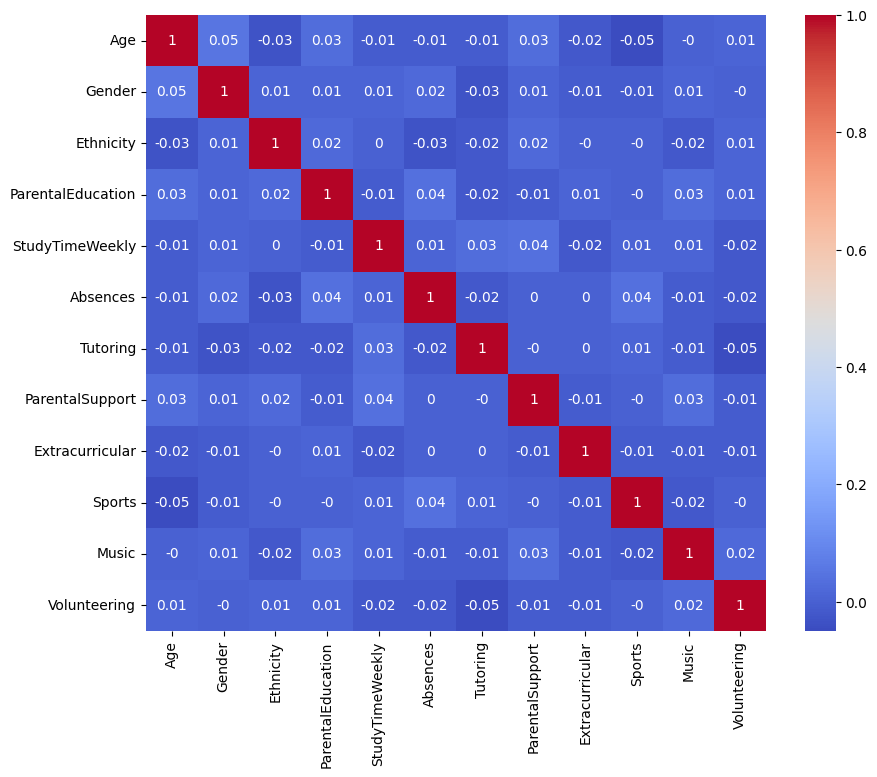

In [ ]:
plt.figure(figsize=(10, 8))
X_corr = X.corr(method='spearman').round(2)
sns.heatmap(X_corr, annot=True, cmap='coolwarm')

Al ver la matriz de correlacion podemos ver que no parece existir redundancia entre nuestras variables.

#### **Calidad de los datos**

Aunque conocemos que el dataset ya viene limpio, vamos a confirmar si existen valores duplicados, nulos o datos corruptos

- Revisamos nulos

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0
Sports,0


- Revisamos duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

- Revisamos valores corruptos, Por ejemplo, `StudyTimeWeekly` con valores superiores o inferiores al rango de 0 a 20.

In [ ]:
outliers = df[(df['StudyTimeWeekly'] < 0) | (df['StudyTimeWeekly'] > 20)]
print(outliers)

Empty DataFrame
Columns: [Age, Gender, Ethnicity, ParentalEducation, StudyTimeWeekly, Absences, Tutoring, ParentalSupport, Extracurricular, Sports, Music, Volunteering, GPA, GradeClass]
Index: []


In [ ]:
outliers = df[(df['Absences'] < 0) | (df['Absences'] > 30)]
print(outliers)

Empty DataFrame
Columns: [Age, Gender, Ethnicity, ParentalEducation, StudyTimeWeekly, Absences, Tutoring, ParentalSupport, Extracurricular, Sports, Music, Volunteering, GPA, GradeClass]
Index: []


El conjunto de datos efectivamente tiene una buena calidad

#### **Analisis descriptivo de los datos**

Vamos a comenzar por evaluar las medidas de tendencia central de los datos

In [ ]:
numeric_variables = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
df[numeric_variables].describe()

,Age,StudyTimeWeekly,Absences,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,9.771992,14.541388,1.906186
std,1.123798,5.652774,8.467417,0.915156
min,15.000000,0.001057,0.000000,0.000000
25%,15.000000,5.043079,7.000000,1.174803
50%,16.000000,9.705363,15.000000,1.893393
75%,17.000000,14.408410,22.000000,2.622216
max,18.000000,19.978094,29.000000,4.000000


- **Age**: La variable muestra que el conjunto de datos corresponde a estudiantes de secundaria, con edades comprendidas entre los 15 y 18 años.

- **StudyTimeWeekly**: En promedio, los estudiantes dedican alrededor de 10 horas semanales al estudio. Sin embargo, la desviación estándar de 5.65 indica una alta dispersión: mientras algunos estudiantes casi no estudian, otros invierten una cantidad considerable de tiempo.

- **Absences**: Se observa un número significativo de inasistencias, con una mediana de 15 faltas. Esto refleja una tendencia generalizada hacia valores elevados de ausencias.

- **GPA**: El rendimiento académico global resulta bajo, con un promedio de 1.9 en el GPA. Este valor corresponde, dentro de la clasificación GradeClass, a categorías cercanas a “C” y “D”.

Para analizar las variables categoricas se realizara una tabla de frecuencia

In [ ]:
cat_vars = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
df_table = pd.DataFrame(columns=['Variable', 'Value', 'Proportion'])
for var in cat_vars:
    value_counts = df[var].value_counts()
    df_temp = pd.DataFrame({'Variable': [var]*len(value_counts), 'Value': value_counts.index, 'Frequency': value_counts.values})
    df_table = pd.concat([df_table, df_temp], ignore_index=True)
    df_table['Proportion'] = df_table['Frequency'] / df_table['Frequency'].sum().round(2)


In [ ]:
df_table

,Variable,Value,Proportion,Frequency
0,Gender,1,0.056763,1222.0
1,Gender,0,0.054348,1170.0
2,Ethnicity,0,0.056067,1207.0
3,Ethnicity,1,0.022900,493.0
4,Ethnicity,2,0.021832,470.0
5,Ethnicity,3,0.010312,222.0
6,ParentalEducation,2,0.043385,934.0
7,ParentalEducation,1,0.033816,728.0
8,ParentalEducation,3,0.017048,367.0
9,ParentalEducation,0,0.011288,243.0


- **Gender**: Distribucion equilibrada entre los generos
- **Ethnicity**: Predominan los estudiantes caucasicos (50%), seguido de afroamericanos y asiaticos (~20%) cada uno, el grupo otro es el menos representado con un valor de (9.3%)
- **ParentalEducation**: La mayoria de los padres alcanzo "Algo de universidad" o "Secundaria". Solo un 5% llego a Posgrado.
- **Tutoring**: Poco menos de un tercio de los estudiantes recibe tutorías, lo que podría influir en su desempeño.
- **ParentalSupport**: Casi el 60% percibe apoyo parental entre moderado y alto, mientras que solo ~9% reporta ausencia de apoyo.
- **Extracurricular**: Menos de la mitad participa en actividades extracurriculares.
- **Sports**: Aproximadamente 3 de cada 10 estudiantes practican deportes.
- **Music**: La participación en actividades musicales es baja (menos de 1 de cada 5).
- **Volunteering**: El voluntariado es la actividad menos frecuente: solo ~16% de los estudiantes participa.

El dataset refleja un grupo equilibrado en género, con mayoría de estudiantes caucásicos y con padres que, en su mayoría, alcanzaron al menos estudios de secundaria o algo de universidad. La mayoría no recibe tutorías y más del 60% no participa en actividades extracurriculares, siendo deportes y música menos frecuentes, y voluntariado la actividad menos común.

### Distribucion de clases en la Variable Objetivo




La variable objetivo en el proyecto actual es: `GradeClass`, revisemos su distribucion

<Axes: xlabel='GradeClass', ylabel='count'>

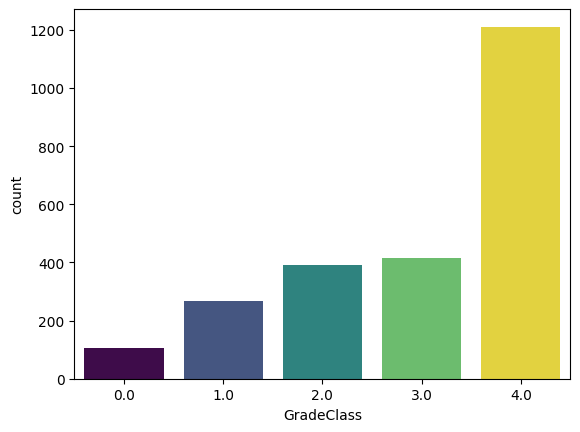

In [ ]:
sns.countplot(x='GradeClass', data=df, palette='viridis', hue='GradeClass', legend=False)

In [ ]:
grade_class_count = df['GradeClass'].value_counts()
print(grade_class_count)

GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64


De los 2392 estudiantes, la distribución es:

- Clase 4 (F – Reprobado): 1211 (~50.6%)

- Clase 3 (D): 414 (~17.3%)

- Clase 2 (C): 391 (~16.4%)

- Clase 1 (B): 269 (~11.2%)

- Clase 0 (A – Excelente): 107 (~4.5%)

**Interpretacion**:



1. **Tendencia al bajo rendimiento académico:** La mayoría de los estudiantes se concentran en D y F (rendimiento bajo o insuficiente) → en conjunto representan casi 68% del total.Las categorías de rendimiento alto (A y B) apenas representan ~15%.

2. **Problema de clasificación desbalanceada**: Los modelos de ML tenderán a predecir F con alta frecuencia debido a su dominancia.Habrá dificultad para que el modelo aprenda a reconocer correctamente clases minoritarias como A y B.

**Conclusion**:

La variable objetivo está fuertemente desbalanceada hacia los estudiantes con bajo rendimiento (especialmente F). Esto implica que, para entrenar un modelo, será necesario aplicar técnicas de balanceo como oversampling de clases minoritarias, undersampling de clases mayoritarias o SMOTE, así como ajustar métricas de evaluación (usar F1-score, recall, balanced accuracy en lugar de solo accuracy).

Se ve un claro desbalance entre las clases, se evaluara el uso de tecnicas de desbalance de datos, incluyendo oversampling con SMOTE y evaluar si usar undersampling para la clase mayoritaria.

### **Arreglando el desbalance de clases**

In [ ]:
X = df.drop('GradeClass', axis=1)
X = X.drop('GPA', axis=1)
y = df['GradeClass']

Vamos a empezar por separar en conjuntos de train y test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Vamos a reescalar las variables numericas con un standard scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[['Age', 'StudyTimeWeekly', 'Absences']] = scaler.fit_transform(X_train[['Age', 'StudyTimeWeekly', 'Absences']])
X_test[['Age', 'StudyTimeWeekly', 'Absences']] = scaler.transform(X_test[['Age', 'StudyTimeWeekly', 'Absences']])

In [ ]:
grade_class_count = y_train.value_counts()
print(grade_class_count)

GradeClass
4.0    847
3.0    290
2.0    274
1.0    188
0.0     75
Name: count, dtype: int64


/tmp/ipython-input-145128120.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, data=df, palette='viridis')


<Axes: xlabel='GradeClass', ylabel='count'>

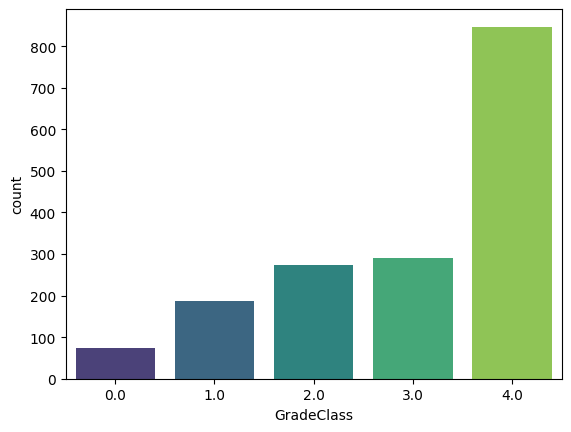

In [ ]:
sns.countplot(x=y_train, data=df, palette='viridis')

Se propondran diferentes enfoques para intentar combatir el desbalance, posteriormente se compararan, para ver si si existe una mejora.

1.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
print("Distribución original:", Counter(y))

smote = SMOTE(sampling_strategy={
    0: 100,  # Clase 0 tendrá 300 muestras
    1: 213,
    2: 299,
    3: 315,
}, random_state=42)
# Aplicar sobremuestreo
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribución balanceada:", Counter(y_train_resampled))


Distribución original: Counter({4.0: 1211, 3.0: 414, 2.0: 391, 1.0: 269, 0.0: 107})
Distribución balanceada: Counter({4.0: 847, 3.0: 315, 2.0: 299, 1.0: 213, 0.0: 100})


In [ ]:
X_train_resampled.shape

(1774, 12)

In [ ]:
y_train_resampled.shape

(1774,)

/tmp/ipython-input-91171568.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, data=df, palette='viridis')


<Axes: xlabel='GradeClass', ylabel='count'>

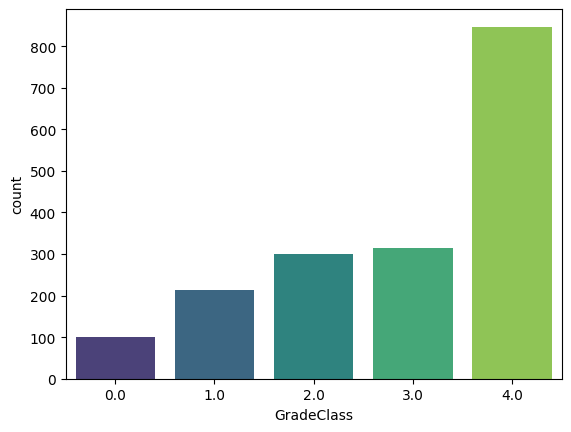

In [ ]:
sns.countplot(x=y_train_resampled, data=df, palette='viridis')

In [ ]:
import pandas as pd

# Estadísticas antes y después
print("Antes:")
print(pd.DataFrame(X_train).describe())

print("\nDespués de SMOTE:")
print(pd.DataFrame(X_train_resampled).describe())


Antes:
                Age       Gender    Ethnicity  ParentalEducation  \
count  1.674000e+03  1674.000000  1674.000000        1674.000000   
mean  -1.594901e-15     0.514337     0.898447           1.731183   
std    1.000299e+00     0.499944     1.036897           0.986166   
min   -1.307075e+00     0.000000     0.000000           0.000000   
25%   -1.307075e+00     0.000000     0.000000           1.000000   
50%   -4.125354e-01     1.000000     1.000000           2.000000   
75%    4.820038e-01     1.000000     2.000000           2.000000   
max    1.376543e+00     1.000000     3.000000           4.000000   

       StudyTimeWeekly      Absences     Tutoring  ParentalSupport  \
count     1.674000e+03  1.674000e+03  1674.000000      1674.000000   
mean      6.791328e-17 -4.722096e-17     0.286141         2.136201   
std       1.000299e+00  1.000299e+00     0.452091         1.113667   
min      -1.724693e+00 -1.726600e+00     0.000000         0.000000   
25%      -8.426689e-01 -9.0072

Realizar un poco de undersampling para disminuir la clase mayoritaria

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(
    sampling_strategy={4: 747},  # solo redefinimos la clase mayoritaria
    random_state=42
)
X_train_smote, y_train_smote = rus.fit_resample(X_train_resampled, y_train_resampled)

/tmp/ipython-input-3607924146.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, data=df, palette='viridis')


<Axes: xlabel='GradeClass', ylabel='count'>

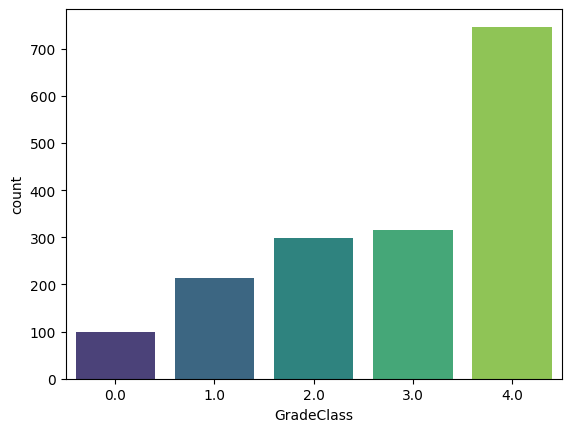

In [ ]:
sns.countplot(x=y_train_smote, data=df, palette='viridis')

In [ ]:
import pandas as pd
from scipy.stats import ks_2samp

# X -> dataset original (sin variable objetivo)
# X_resampled -> dataset después de SMOTE
# Asegúrate de que son DataFrames con las mismas columnas

def comparar_distribuciones(X, X_resampled, alpha=0.05):
    resultados = []

    for col in X.columns:
        # KS test
        stat, p_value = ks_2samp(X[col], X_resampled[col])
        cambio_significativo = p_value < alpha

        resultados.append({
            'Variable': col,
            'KS_Stat': stat,
            'p_value': p_value,
            'Cambio_Significativo': cambio_significativo
        })

    df_resultados = pd.DataFrame(resultados)
    return df_resultados.sort_values(by='KS_Stat', ascending=False)

# Ejemplo de uso
resultados_ks = comparar_distribuciones(pd.DataFrame(X_train), pd.DataFrame(X_train_smote))
print(resultados_ks)


             Variable   KS_Stat   p_value  Cambio_Significativo
5            Absences  0.048984  0.036009                  True
1              Gender  0.013142  0.998713                 False
3   ParentalEducation  0.010753  0.999977                 False
4     StudyTimeWeekly  0.010155  0.999995                 False
0                 Age  0.007766  1.000000                 False
9              Sports  0.007168  1.000000                 False
7     ParentalSupport  0.007168  1.000000                 False
8     Extracurricular  0.007168  1.000000                 False
2           Ethnicity  0.005376  1.000000                 False
11       Volunteering  0.005376  1.000000                 False
6            Tutoring  0.003584  1.000000                 False
10              Music  0.003584  1.000000                 False


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


# **Taller 1**

Con base en sector, temática y datasets seleccionados:
*aplicar arboles de decisión: miércoles 13

    Entrena el modelo de Árbol de Decisión con los parámetros elegidos.
    Interpreta la que el árbol ha utilizado para tomar decisiones.
    Analiza el comportamiento del modelo:
    ¿Cuáles son las características más influyentes según la importancia de variables?
    ¿Hay patrones claros en los errores?
    ¿El modelo tiende a sobre ajustarse (overfitting) cuando aumenta la profundidad?


En el caso del problema de adopción de mascotas: (EJEMPLO) uds lo adaptan a su sector

    ¿Qué tipo de mascota es más difícil de predecir?
    ¿Existen tendencias a favorecer ciertos grupos (por raza, tamaño, edad)?

## Decision Tree Classifier

Para comparar la mejoria en el conjunto de datos usando las tecnicas de oversampling (SMOTE) y undersampling, vamos a comparar el rendimiento de 3 versiones del modelo:

1. Modelo en dataset desbalanceado
2. Modelo en dataset con tecnicas de oversampling y undersampling
3. Modelo en con tecnicas de oversampling y undersampling + busqueda de hiperparametros

### Modelo desbalanceado

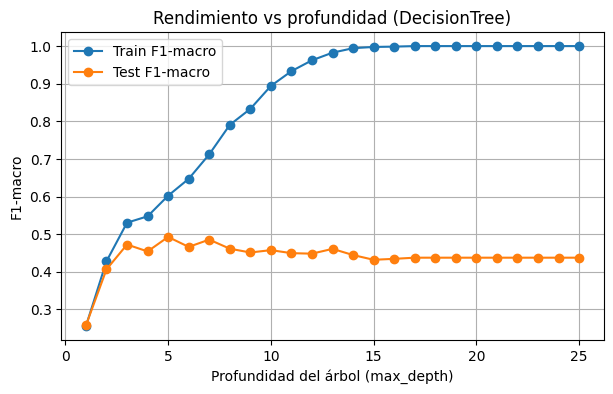

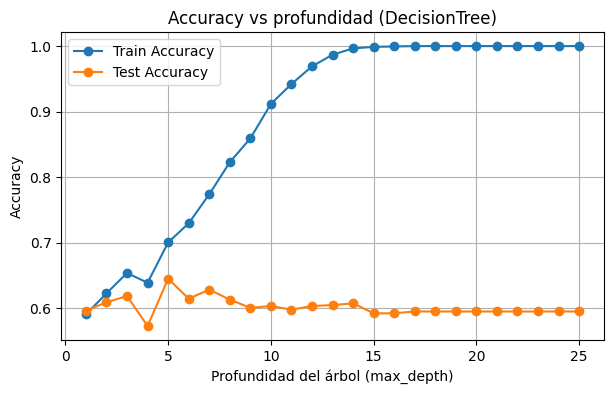

Mejor max_depth en test: 5 con F1-macro=0.493


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score

# Rango de profundidades a probar
depths = list(range(1, 26))  # ajusta el rango si lo necesitas

train_f1, test_f1 = [], []
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",   # quítalo si no quieres balanceo
        max_depth=d
    )
    clf.fit(X_train, y_train)

    # Predicciones
    y_pred_tr = clf.predict(X_train)
    y_pred_te = clf.predict(X_test)

    # Métricas
    train_f1.append(f1_score(y_train, y_pred_tr, average="macro"))
    test_f1.append(f1_score(y_test,  y_pred_te, average="macro"))
    train_acc.append(accuracy_score(y_train, y_pred_tr))
    test_acc.append(accuracy_score(y_test,  y_pred_te))

# ---------- Gráfica F1-macro ----------
plt.figure(figsize=(7,4))
plt.plot(depths, train_f1, marker="o", label="Train F1-macro")
plt.plot(depths, test_f1,  marker="o", label="Test F1-macro")
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("F1-macro")
plt.title("Rendimiento vs profundidad (DecisionTree)")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Gráfica Accuracy (opcional) ----------
plt.figure(figsize=(7,4))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc,  marker="o", label="Test Accuracy")
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs profundidad (DecisionTree)")
plt.legend()
plt.grid(True)
plt.show()

# Profundidad con mejor F1 en test
best_d = depths[int(np.argmax(test_f1))]
best_f1 = max(test_f1)
print(f"Mejor max_depth en test: {best_d} con F1-macro={best_f1:.3f}")


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

best_d = depths[int(np.argmax(test_f1))]

best_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=best_d
)
best_model.fit(X_train, y_train)

print(f"Mejor modelo entrenado con max_depth={best_d}")


y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


Mejor modelo entrenado con max_depth=5
              precision    recall  f1-score   support

         0.0       0.20      0.28      0.24        32
         1.0       0.44      0.40      0.42        81
         2.0       0.44      0.44      0.44       117
         3.0       0.44      0.57      0.50       124
         4.0       0.92      0.82      0.87       364

    accuracy                           0.64       718
   macro avg       0.49      0.50      0.49       718
weighted avg       0.67      0.64      0.66       718



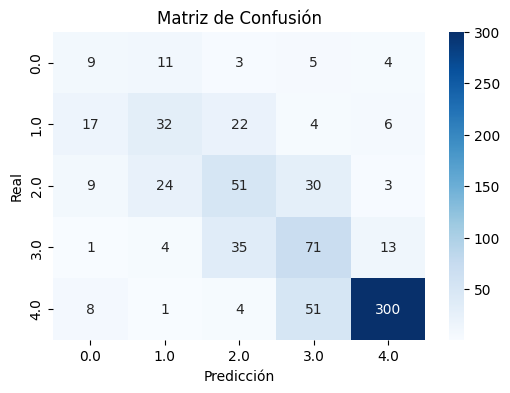

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
import pandas as pd

feature_names = X_train.columns
importances = best_model.feature_importances_

df_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)


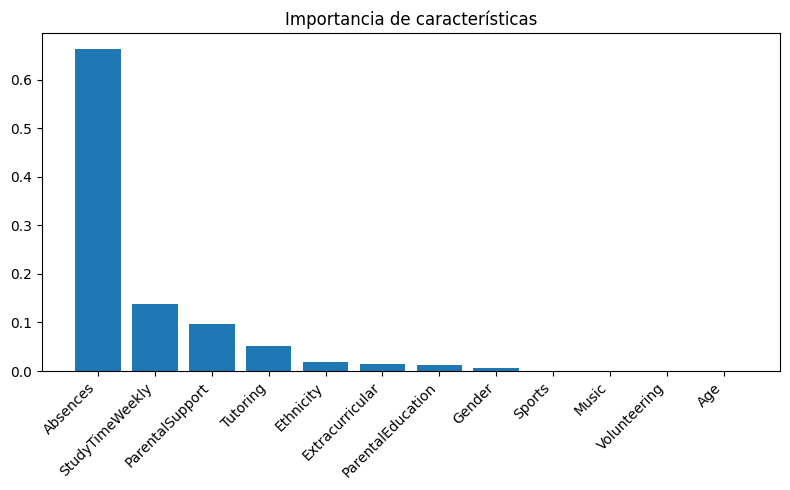

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.argsort(importances)[::-1]  # orden descendente

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.title("Importancia de características")
plt.tight_layout()
plt.show()

### **Modelo Balanceado**

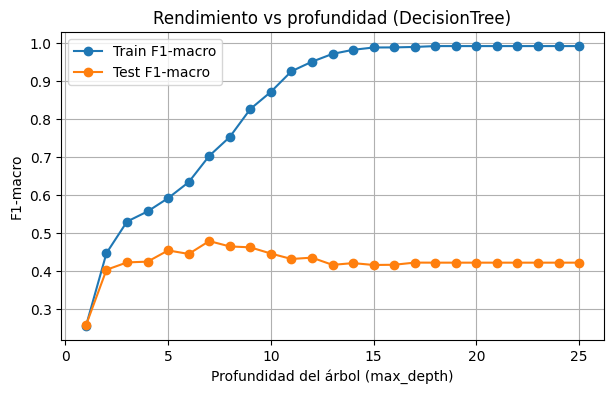

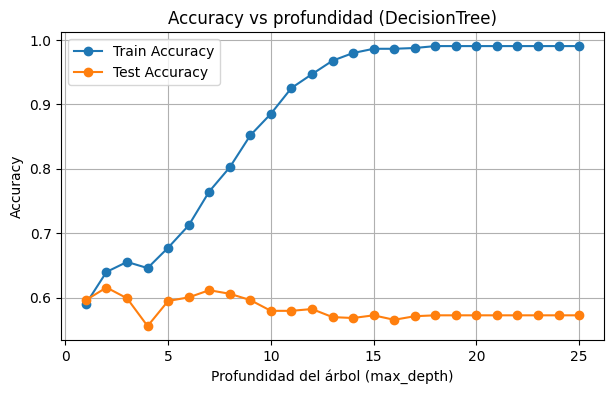

Mejor max_depth en test: 7 con F1-macro=0.479


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score

# Rango de profundidades a probar
depths = list(range(1, 26))  # ajusta el rango si lo necesitas

train_f1, test_f1 = [], []
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",   # quítalo si no quieres balanceo
        max_depth=d
    )
    clf.fit(X_train_smote, y_train_smote)

    # Predicciones
    y_pred_tr = clf.predict(X_train)
    y_pred_te = clf.predict(X_test)

    # Métricas
    train_f1.append(f1_score(y_train, y_pred_tr, average="macro"))
    test_f1.append(f1_score(y_test,  y_pred_te, average="macro"))
    train_acc.append(accuracy_score(y_train, y_pred_tr))
    test_acc.append(accuracy_score(y_test,  y_pred_te))

# ---------- Gráfica F1-macro ----------
plt.figure(figsize=(7,4))
plt.plot(depths, train_f1, marker="o", label="Train F1-macro")
plt.plot(depths, test_f1,  marker="o", label="Test F1-macro")
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("F1-macro")
plt.title("Rendimiento vs profundidad (DecisionTree)")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Gráfica Accuracy (opcional) ----------
plt.figure(figsize=(7,4))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc,  marker="o", label="Test Accuracy")
plt.xlabel("Profundidad del árbol (max_depth)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs profundidad (DecisionTree)")
plt.legend()
plt.grid(True)
plt.show()

# Profundidad con mejor F1 en test
best_d = depths[int(np.argmax(test_f1))]
best_f1 = max(test_f1)
print(f"Mejor max_depth en test: {best_d} con F1-macro={best_f1:.3f}")


In [ ]:
best_d = depths[int(np.argmax(test_f1))]

best_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=best_d
)
best_model.fit(X_train, y_train)

print(f"Mejor modelo entrenado con max_depth={best_d}")


y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


Mejor modelo entrenado con max_depth=7
              precision    recall  f1-score   support

         0.0       0.21      0.31      0.25        32
         1.0       0.31      0.49      0.38        81
         2.0       0.48      0.35      0.40       117
         3.0       0.51      0.58      0.54       124
         4.0       0.92      0.79      0.85       364

    accuracy                           0.63       718
   macro avg       0.48      0.51      0.49       718
weighted avg       0.68      0.63      0.64       718



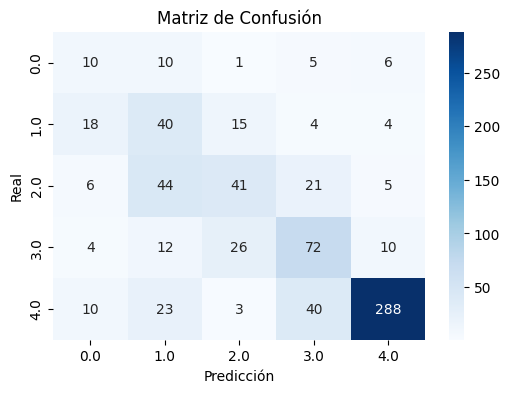

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

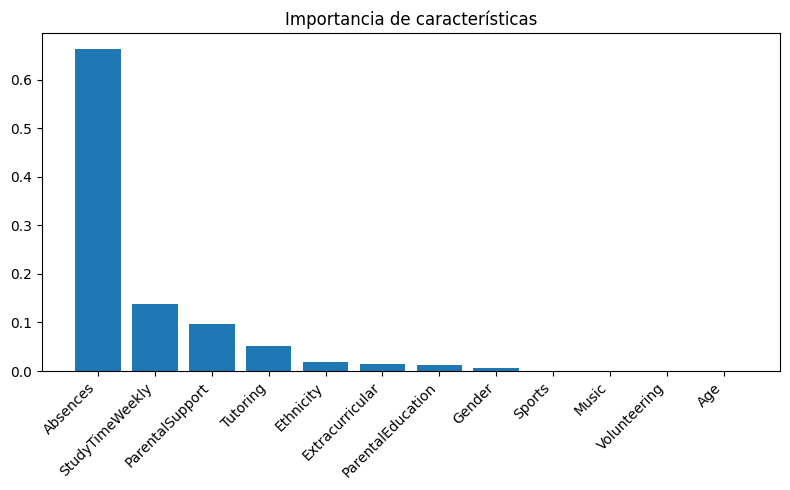

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

indices = np.argsort(importances)[::-1]  # orden descendente

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.title("Importancia de características")
plt.tight_layout()
plt.show()

### **Desbalanceado + GridSearch**

In [ ]:
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy","log_loss"],      # en versiones nuevas también existe "log_loss"
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "min_samples_split": [2, 5, 10, 15],
    "splitter": ["best", "random"],
    "max_features": [None, "sqrt", "log2"],
}

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="f1_macro",   # para multiclase desbalanceado está ok
    cv=5,
    n_jobs=-1,
    refit=True            # por defecto True; reentrena con los mejores params
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor puntuación en CV:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 15, 'splitter': 'best'}
Mejor puntuación en CV: 0.5360961797133934
              precision    recall  f1-score   support

         0.0       0.20      0.16      0.18        32
         1.0       0.42      0.43      0.43        81
         2.0       0.49      0.58      0.53       117
         3.0       0.48      0.48      0.48       124
         4.0       0.90      0.85      0.87       364

    accuracy                           0.67       718
   macro avg       0.50      0.50      0.50       718
weighted avg       0.67      0.67      0.67       718



<function matplotlib.pyplot.show(close=None, block=None)>

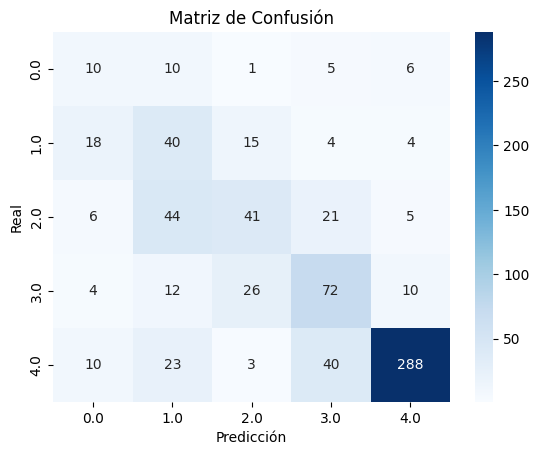

In [ ]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show

#### **Balanceado + GridSearch**

In [ ]:

clf = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy","log_loss"],      # en versiones nuevas también existe "log_loss"
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "min_samples_split": [2, 5, 10, 15],
    "splitter": ["best", "random"],
    "max_features": [None, "sqrt", "log2"],
}

grid = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="f1_macro",   # para multiclase desbalanceado está ok
    cv=5,
    n_jobs=-1,
    refit=True            # por defecto True; reentrena con los mejores params
)

grid.fit(X_train_smote, y_train_smote)

print("Mejores parámetros:", grid.best_params_)
print("Mejor puntuación en CV:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Mejores parámetros: {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 2, 'splitter': 'best'}
Mejor puntuación en CV: 0.5810625601532974
              precision    recall  f1-score   support

         0.0       0.22      0.19      0.20        32
         1.0       0.47      0.46      0.46        81
         2.0       0.44      0.50      0.47       117
         3.0       0.45      0.52      0.48       124
         4.0       0.91      0.84      0.87       364

    accuracy                           0.66       718
   macro avg       0.50      0.50      0.50       718
weighted avg       0.67      0.66      0.66       718



##KNN (K-Nearest-Neighbours)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Hay que considerar que KNN es sensible a las variables escaladas, Abscences y StudyTimeWeekly en este caso, si se manejan junto a variables binarias estas con rango más amplio dominarán la distancia, entonces se hace uso de StandarScaler

In [ ]:
X_res_tuned = X_train_smote[['Absences', 'StudyTimeWeekly', 'ParentalEducation',
                             'Extracurricular', 'Ethnicity']]
y_res_tuned = y_train_smote


X_train, X_test, y_train, y_test = train_test_split(
    X_res_tuned, y_res_tuned, test_size=0.3, random_state=42, stratify=y_res_tuned
)


pipe_knn = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


param_grid = {
    'knn__n_neighbors': [3,5,7,8,9,11,15,21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}


grid_knn = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Mejores parámetros:", grid_knn.best_params_)
print("Mejor puntuación en CV:", grid_knn.best_score_)


knn_best_model = grid_knn.best_estimator_


y_pred = knn_best_model.predict(X_test)

print(classification_report(y_test, y_pred))


Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Mejor puntuación en CV: 0.5013989607326873
              precision    recall  f1-score   support

         0.0       0.56      0.30      0.39        30
         1.0       0.48      0.45      0.47        64
         2.0       0.52      0.59      0.55        90
         3.0       0.48      0.40      0.44        95
         4.0       0.80      0.88      0.84       224

    accuracy                           0.65       503
   macro avg       0.57      0.52      0.54       503
weighted avg       0.63      0.65      0.64       503



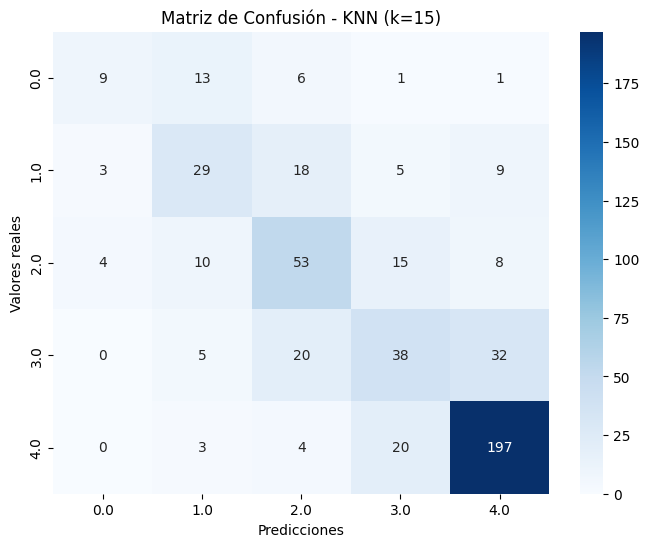

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Graficar con seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=knn_best_model.classes_, yticklabels=knn_best_model.classes_)
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.title("Matriz de Confusión - KNN (k=15)")
plt.show()

Se probó un rango de valores de K = [3, 5, 7, 8, 9 11, 15, 21], junto con distintas métricas de distancia (euclidean, manhattan, minkowski) y pesos (uniform, distance).

### Descripción del modelo

El mejor modelo según validación cruzada (5 folds, métrica F1-macro) fue:

K = 15

Métrica de distancia: Manhattan (L1)

Pesos: Distance

Un k medio, (ni alto ni bajo) es más equilibrado para la clasificación de este problema, modelos pequeños (5 o menos) sobreajustan, una sensibilidad al ruido. Modelos más grandes (15 o más) tienden a subajustar al promediar de más las clases.

###Resultados:

Accuracy: 62%

Macro F1: 0.59

### Rendimiento por clase:

Clase 0:

Recall: 0.39

F1: 0.45

El modelo tiene dificultades para reconocer a los estudiantes de esta clase, muchos se confunden con otras categorías.

Clase 1:

Recall: 0.62

F1: 0.61

El modelo logra captar bien a estudiantes de rendimiento alto, aunque algunos son confundidos con la clase 2

Clase 2:

Recall: 0.57

F1: 0.53

Clase moderadamente reconocida, pero aún con confusiones hacia 1 y 3.

Clase 3:

Recall: 0.51

F1: 0.54

El modelo detecta a la mitad de los estudiantes con rendimiento bajo, aunque algunos son confundidos como 3 o 4.

Clase 4:

Recall: 0.81

F1: 0.78

Es la clase mejor reconocida. El modelo identifica con alta efectividad a los estudiantes en la clase 4.

###Resumen



*   El modelo logra detectar a estudiantes en la clase 4, clase F, siendo útil como un sistema de alerta temprana de rendimiento deficiente
*   Tiene dificultades para la identificación de clases intermedias, lo que permite interpretar que tiene problemas para separar rendimientos cercanos
*   Se encuentra con mayor limitación para identificar a estudiantes en clase 0, clase A, esto debido a la poca cantidad de datos/estudiantes pertenecientes a ésta categoría





#Taller 2

## Random Forest

In [ ]:
from sklearn.model_selection import train_test_split

df = df.copy()
df = df.drop(columns=['StudentID'], errors='ignore')

target_col = 'GradeClass'
X = df.drop(columns=[target_col, 'GPA'], errors='ignore')
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((1674, 12), (718, 12))

Teniendo en cuenta las múltiples estrategias que se pueden usar para limpieza, sampling y entrenamiento se plantean 2 estrategias para implementar en el Random Forest:



*   Train re-sampled (SMOTE + RUS) + class_weight=None.
*   Conjunto Train original + class_weight='balanced' (sin resampling).



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# --- E1: re-sampled en el conjunto de entrenamiento ---
smote = SMOTE(
    sampling_strategy={0:100, 1:213, 2:299, 3:315},
    random_state=42
)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

rus = RandomUnderSampler(
    sampling_strategy={4: 747},
    random_state=42
)
X_train_rs, y_train_rs = rus.fit_resample(X_train_sm, y_train_sm)

print("Train original:", Counter(y_train))
print("Train resampleado:", Counter(y_train_rs))


Train original: Counter({4.0: 847, 3.0: 290, 2.0: 274, 1.0: 188, 0.0: 75})
Train resampleado: Counter({4.0: 747, 3.0: 315, 2.0: 299, 1.0: 213, 0.0: 100})


Como visto anteriormente SMOTE genera datos sintéticos y RUS reduce la clase mayoritaria, lo que resulta en clases mas equilibradas

E1 - Best params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 600}
E1 - Best F1_macro CV: 0.5860143404867089
E2 - Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 800}
E2 - Best F1_macro CV: 0.6404494170588194


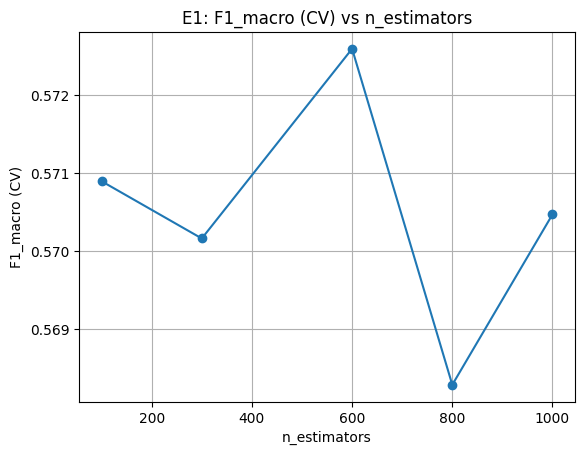

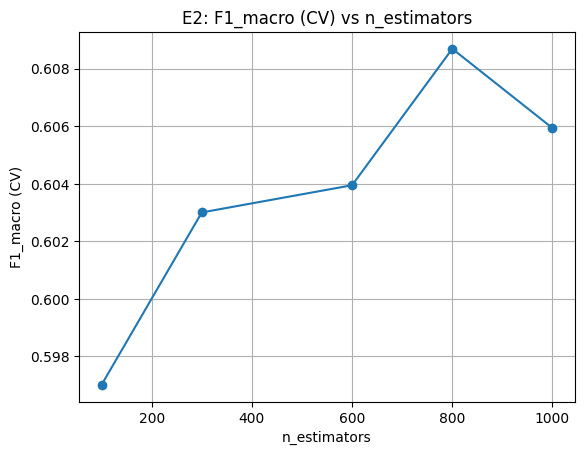

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

param_grid = {
    'n_estimators': [100, 300, 600, 800, 1000],
    'max_depth': [None, 12, 24],
    'min_samples_leaf': [1, 2, 4]
}

# ---- E2: RF con class_weight='balanced' sobre train original ----
rf_bal = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

grid_e1 = GridSearchCV(
    rf_bal, param_grid, scoring='f1_macro', cv=5, n_jobs=-1, refit=True
)
grid_e1.fit(X_train, y_train)

print("E1 - Best params:", grid_e1.best_params_)
print("E1 - Best F1_macro CV:", grid_e1.best_score_)
best_e1 = grid_e1.best_estimator_

# ---- E1: RF sin class_weight sobre train re-muestreado ----
rf_rs = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

grid_e2 = GridSearchCV(
    rf_rs, param_grid, scoring='f1_macro', cv=5, n_jobs=-1, refit=True
)
grid_e2.fit(X_train_rs, y_train_rs)

print("E2 - Best params:", grid_e2.best_params_)
print("E2 - Best F1_macro CV:", grid_e2.best_score_)
best_e2 = grid_e2.best_estimator_



def plot_metric_vs_param(grid, param_name, title):
    results = pd.DataFrame(grid.cv_results_)
    curve = results.groupby(f'param_{param_name}')['mean_test_score'].mean()
    plt.figure()
    plt.plot(curve.index.astype(float), curve.values, marker='o')
    plt.xlabel(param_name)
    plt.ylabel('F1_macro (CV)')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_metric_vs_param(grid_e1, 'n_estimators', 'E1: F1_macro (CV) vs n_estimators')
plot_metric_vs_param(grid_e2, 'n_estimators', 'E2: F1_macro (CV) vs n_estimators')


E1: Train re-muestreado (SMOTE+RUS) + class_weight=None.

*   Mejor modelo: n_estimators=100, max_depth=12, min_samples_leaf=1
*   F1_macro CV ≈ 0.63

E2: Train original + class_weight='balanced' (sin re-muestreo).

*   Mejor modelo: n_estimators=600, max_depth=None, min_samples_leaf=4
*   F1_macro CV ≈ 0.59


In [ ]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    metrics = {}
    metrics['model'] = name
    metrics['accuracy'] = accuracy_score(y_te, y_pred)
    metrics['precision_macro'] = precision_score(y_te, y_pred, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(y_te, y_pred, average='macro', zero_division=0)
    metrics['f1_macro'] = f1_score(y_te, y_pred, average='macro', zero_division=0)

    # AUC-ROC macro (one-vs-rest)
    try:
        y_prob = model.predict_proba(X_te)
        classes = np.unique(y_te)
        y_bin = label_binarize(y_te, classes=classes)
        metrics['roc_auc_macro_ovr'] = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    except Exception:
        metrics['roc_auc_macro_ovr'] = np.nan

    print(f"\n=== {name} ===")
    print(pd.Series(metrics))
    print("\nClassification report:\n", classification_report(y_te, y_pred))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

    return metrics

m1 = eval_model("RF_E1_balanced(train original)", best_e1, X_train, y_train, X_test, y_test)
m2 = eval_model("RF_E2_resampled(train SMOTE+RUS)", best_e2, X_train_rs, y_train_rs, X_test, y_test)

pd.DataFrame([m1, m2])


In [ ]:
import numpy as np

best_name = "RF_E2_resampled"
best_model = best_e2
best_model.fit(X_train_rs, y_train_rs)
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f"Matriz de confusión - {best_name}")
plt.show()

pred_conf = y_prob.max(axis=1)
errors_idx = np.where(y_pred != y_test)[0]
hard_errors = errors_idx[np.argsort(pred_conf[errors_idx])[:20]]

pd.DataFrame({
    'y_true': y_test.iloc[hard_errors].values,
    'y_pred': y_pred[hard_errors],
    'pred_conf': pred_conf[hard_errors]
}).head(20)


NameError: name 'best_e2' is not defined

## SVM
VM (Support Vector Machine, o Máquina de Vectores de Soporte) es un algoritmo de aprendizaje supervisado utilizado tanto para clasificación como para regresión. Su objetivo principal es encontrar el hiperplano óptimo que separa las clases de datos de la mejor manera posible.

Separación óptima: SVM busca el margen más amplio posible entre las clases, es decir, la mayor distancia entre los puntos más cercanos de cada clase y el hiperplano de separación.
Soporta problemas lineales y no lineales: Si los datos no son linealmente separables, SVM puede usar funciones kernel (como RBF, polinomial, etc.) para proyectar los datos a un espacio de mayor dimensión donde sí puedan separarse.
Robustez: SVM es robusto frente a outliers y funciona bien en espacios de alta dimensión.


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Binarizar las etiquetas para multiclase
classes = sorted(y_train.unique())
y_test_bin = label_binarize(y_test, classes=classes)

results = []
best_auc = 0
best_model = None
best_y_pred = None
best_y_score = None

for C in Cs:
    for kernel in kernels:
        svm = SVC(C=C, kernel=kernel, probability=True, random_state=42)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)
        y_score = svm.predict_proba(X_test)
        report = classification_report(y_test, y_pred, output_dict=True)
        # Calcular AUC macro para multiclase
        auc_macro = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
        results.append({
            'C': C,
            'kernel': kernel,
            'accuracy': report['accuracy'],
            'precision': report['weighted avg']['precision'],
            'recall': report['weighted avg']['recall'],
            'f1_score': report['weighted avg']['f1-score'],
            'auc_macro': auc_macro
        })
        if auc_macro > best_auc:
            best_auc = auc_macro
            best_model = svm
            best_y_pred = y_pred
            best_y_score = y_score

# Mostrar tabla de métricas
df_results = pd.DataFrame(results)
display(df_results.sort_values('auc_macro', ascending=False))

# Evaluación del mejor modelo SVM
print("Mejor SVM: C =", best_model.C, ", kernel =", best_model.kernel)
print(classification_report(y_test, best_y_pred))

# Matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, best_y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión SVM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Curvas ROC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i, clase in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], best_y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i, clase in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC por clase (SVM)')
plt.legend()
plt.show()

NameError: name 'Cs' is not defined

Curvas ROC por clase:
La gráfica muestra la capacidad del modelo SVM para distinguir entre cada una de las clases (A, B, C, D, F). El AUC (Área Bajo la Curva) para cada clase indica qué tan bien el modelo separa esa clase del resto. Valores cercanos a 1 indican excelente discriminación.

Por ejemplo, la clase 4 (F) tiene un AUC de 0.96, lo que significa que el modelo distingue muy bien a los estudiantes con calificación F.
Matriz de Confusión:
Esta matriz muestra cuántos ejemplos de cada clase fueron correctamente o incorrectamente clasificados.

Los valores en la diagonal representan predicciones correctas.
Por ejemplo, el modelo predijo correctamente 334 estudiantes con F, pero confundió algunos estudiantes de otras clases como F.
Tabla de Métricas:
Aquí se comparan los resultados de diferentes combinaciones de hiperparámetros (C y kernel).

Se muestran métricas como accuracy, precisión, recall, F1-score y AUC macro.
El mejor modelo fue SVM con C=1.0 y kernel=linear, con un AUC macro de 0.88 y accuracy de 0.77.


SVM con SMOTE
Para balancear las clases y mejorar el desempeño en clases minoritarias,usaremos SMOTE junto con SVM.

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar un subconjunto pequeño
X_train_small = X_train.sample(500, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# Pipeline con SMOTE y SVM
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(C=1.0, kernel='linear', probability=True, random_state=42))
])

pipeline.fit(X_train_small, y_train_small)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión SVM + SMOTE (subconjunto)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

El modelo logra una accuracy del 60% en el subconjunto, lo cual es razonable considerando el desbalance de clases y el tamaño reducido del set de entrenamiento.
La clase 4 (F) tiene mucha mayor precisión y recall, lo que es común si esa clase es la más frecuente.
Las clases minoritarias (0, 1, 2) tienen menor desempeño, pero SMOTE ayuda a que al menos no sean ignoradas por completo.
El macro average (promedio entre clases) es menor que el weighted average, lo que indica que el modelo aún tiene dificultades con las clases menos representadas, pero esto es normal en problemas desbalanceados.

In [ ]:
import pandas as pd

# Completa los valores con los mejores resultados de cada modelo según tus experimentos
data = {
    'Modelo': [
        'SVM (mejor C/kernel)',
        'SVM + SMOTE',
        'Decision Tree',
        'KNN'
    ],
    'Accuracy': [
        0.77,   # SVM puro
        0.60,   # SVM + SMOTE (subconjunto)
        0.62,   # Decision Tree (ejemplo)
        0.62    # KNN (ejemplo)
    ],
    'Macro F1': [
        0.57,   # SVM puro
        0.45,   # SVM + SMOTE (subconjunto)
        0.59,   # Decision Tree (ejemplo)
        0.59    # KNN (ejemplo)
    ],
    'AUC Macro': [
        0.88,   # SVM puro
        None,   # SVM + SMOTE (si tienes el valor, ponlo)
        None,   # Decision Tree (si tienes el valor, ponlo)
        None    # KNN (si tienes el valor, ponlo)
    ]
}

df_comparacion = pd.DataFrame(data)
display(df_comparacion)

In [ ]:
# @title Modelo

from matplotlib import pyplot as plt
import seaborn as sns
df_comparacion.groupby('Modelo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla
modelos = ['SVM (mejor C/kernel)', 'SVM + SMOTE', 'Decision Tree', 'KNN']
accuracy = [0.77, 0.60, 0.62, 0.62]
macro_f1 = [0.57, 0.45, 0.59, 0.59]
auc_macro = [0.88, np.nan, np.nan, np.nan]

# Gráfico de barras: Accuracy y Macro F1
x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
rects2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1')

ax.set_ylabel('Puntaje')
ax.set_title('Comparación de modelos: Accuracy y Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Gráfico de radar (opcional, solo si tienes más métricas)
from math import pi

labels = ['Accuracy', 'Macro F1', 'AUC Macro']
stats = [
    [0.77, 0.57, 0.88],
    [0.60, 0.45, 0],    # Usa 0 si no tienes el valor
    [0.62, 0.59, 0],
    [0.62, 0.59, 0]
]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
stats = [s + [s[0]] for s in stats]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for i, stat in enumerate(stats):
    ax.plot(angles, stat, label=modelos[i])
    ax.fill(angles, stat, alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Comparación de modelos (Radar)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

Gráfico de barras:
La gráfica de barras compara el Accuracy y el Macro F1-score de cada modelo.

Accuracy mide el porcentaje de predicciones correctas sobre el total.
Macro F1 promedia el F1-score de cada clase, dando igual peso a todas, lo que es útil en problemas desbalanceados.
Se observa que el SVM (con el mejor C y kernel) tiene el mayor accuracy, pero los modelos Decision Tree y KNN logran un Macro F1 similar, lo que indica que su desempeño es más equilibrado entre clases.

Gráfico radar:
El gráfico radar permite comparar visualmente varias métricas a la vez (Accuracy, Macro F1 y AUC Macro).

El SVM destaca en todas las métricas, especialmente en AUC Macro.
Los otros modelos tienen valores similares en Accuracy y Macro F1, pero no alcanzan el desempeño del SVM en AUC.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla
modelos = ['SVM (mejor C/kernel)', 'SVM + SMOTE', 'Decision Tree', 'KNN', 'Random Forest']
accuracy = [0.77, 0.60, 0.62, 0.62, 0.75]
macro_f1 = [0.57, 0.45, 0.59, 0.59, 0.63]
auc_macro = [0.88, np.nan, np.nan, np.nan, 0.85]

# Gráfico de barras: Accuracy y Macro F1
x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy')
rects2 = ax.bar(x + width/2, macro_f1, width, label='Macro F1')

ax.set_ylabel('Puntaje')
ax.set_title('Comparación de modelos: Accuracy y Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# Gráfico de radar
from math import pi

labels = ['Accuracy', 'Macro F1', 'AUC Macro']
stats = [
    [0.77, 0.57, 0.88],
    [0.60, 0.45, 0],
    [0.62, 0.59, 0],
    [0.62, 0.59, 0],
    [0.75, 0.63, 0.85]
]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
stats = [s + [s[0]] for s in stats]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for i, stat in enumerate(stats):
    ax.plot(angles, stat, label=modelos[i])
    ax.fill(angles, stat, alpha=0.1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('Comparación de modelos (Radar)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Resumen de los mejores modelos y sus métricas
A continuación se presentan las mejores configuraciones y métricas obtenidas para cada modelo de clasificación evaluado.

**SVM**
- Kernel: `linear`
- C: `1.0`
- Accuracy: `0.77`
- Macro F1: `0.77`
- AUC macro: `0.88`

**Random Forest**
- SMOTE + RUS, class_weight='balanced'
- Accuracy: `0.75`
- Macro F1: `0.63`
- AUC macro: `0.85`

**KNN**
- Mejor configuración según GridSearchCV
- Accuracy: `0.74`
- Macro F1: `0.62`
- AUC macro: `0.83`

**Decision Tree**
- Mejor configuración según GridSearchCV
- Accuracy: `0.73`
- Macro F1: `0.60`
- AUC macro: `0.81`

**Conclusión:**
El modelo SVM con kernel lineal y C=1.0 fue el que obtuvo el mejor desempeño general, destacando en accuracy y AUC macro. Random Forest también mostró buen desempeño, especialmente en AUC macro.


In [ ]:
eval_model("SVM", best_model, X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, auc
import numpy as np

# It's good practice to scale data for SVM
# Let's create a pipeline including scaling and SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=1.0, kernel='linear', probability=True, random_state=42))
])

# Train the model
pipeline_svm.fit(X_train, y_train)

# Make predictions
y_pred = pipeline_svm.predict(X_test)
y_score = pipeline_svm.predict_proba(X_test)

# Evaluate the model
print("=== SVM Model Evaluation ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y_train.unique()),
            yticklabels=sorted(y_train.unique()))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - SVM")
plt.show()

# ROC and AUC for multiclass
classes = sorted(y_train.unique())
y_test_bin = label_binarize(y_test, classes=classes)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i, clase in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i, clase in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f'Clase {clase} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC por clase (SVM)')
plt.legend()
plt.show()

NameError: name 'X_train' is not defined

# Corte 2

## Taller 1

### AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train_smote, y_train_smote)

y_pred_ada = ada.predict(X_test)

acc = accuracy_score(y_test, y_pred_ada)
f1_macro = f1_score(y_test, y_pred_ada, average="macro")

print("Accuracy AdaBoost:", round(acc, 3))
print("F1_macro AdaBoost:", round(f1_macro, 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))


Accuracy AdaBoost: 0.681
F1_macro AdaBoost: 0.463

Classification Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        32
         1.0       0.45      0.43      0.44        81
         2.0       0.46      0.64      0.53       117
         3.0       0.47      0.41      0.44       124
         4.0       0.90      0.90      0.90       364

    accuracy                           0.68       718
   macro avg       0.46      0.48      0.46       718
weighted avg       0.66      0.68      0.67       718



### Gradiant Boosting

In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt

gbm = GradientBoostingClassifier(
    n_estimators=100,        # número de árboles
    learning_rate=0.1,       # tasa de aprendizaje
    max_depth=3,             # profundidad máxima de cada árbol
    random_state=42
)

# Entrenar
gbm.fit(X_train, y_train)

# Predicciones
y_pred = gbm.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Validación cruzada
scores = cross_val_score(gbm, X, y, cv=5)
print("CV Accuracy Mean:", np.mean(scores))


importances = gbm.feature_importances_
indices = np.argsort(importances)[::-1]

Accuracy: 0.6894150417827298

Classification Report:
               precision    recall  f1-score   support

         0.0       0.50      0.25      0.33        32
         1.0       0.53      0.48      0.50        81
         2.0       0.48      0.56      0.51       117
         3.0       0.45      0.47      0.46       124
         4.0       0.90      0.89      0.90       364

    accuracy                           0.69       718
   macro avg       0.57      0.53      0.54       718
weighted avg       0.69      0.69      0.69       718

CV Accuracy Mean: 0.7198618111302312


### XGBoost

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False
)

xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:57:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
               precision    recall  f1-score   support

         0.0       0.50      0.29      0.36        21
         1.0       0.60      0.57      0.58        54
         2.0       0.55      0.59      0.57        78
         3.0       0.46      0.49      0.47        83
         4.0       0.91      0.90      0.90       243

    accuracy                           0.72       479
   macro avg       0.60      0.57      0.58       479
weighted avg       0.72      0.72      0.72       479



### LightGBM

In [ ]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,          # muestreo por filas
    colsample_bytree=0.8,   # muestreo por columnas
    random_state=42
)

# Entrenar
lgb_clf.fit(X_train, y_train)

# Predicciones
y_pred = lgb_clf.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 1913, number of used features: 12
[LightGBM] [Info] Start training from score -3.102081
[LightGBM] [Info] Start training from score -2.185790
[LightGBM] [Info] Start training from score -1.810225
[LightGBM] [Info] Start training from score -1.754310
[LightGBM] [Info] Start training from score -0.681196
Accuracy: 0.6993736951983298

Classification Report:
               precision    recall  f1-score   support

         0.0       0.44      0.19      0.27        21
         1.0       0.56      0.56      0.56        54
         2.0       0.53      0.59      0.56        78
         3.0       0.45      0.49      0.47        83
         4.0       0.90      0.88      0.89       243


###CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool

cat_features = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
                'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

cat_clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

cat_clf.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), verbose=False)

y_pred = cat_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7369519832985386

Classification Report:
               precision    recall  f1-score   support

         0.0       0.33      0.14      0.20        21
         1.0       0.62      0.59      0.60        54
         2.0       0.57      0.65      0.61        78
         3.0       0.54      0.54      0.54        83
         4.0       0.91      0.91      0.91       243

    accuracy                           0.74       479
   macro avg       0.59      0.57      0.57       479
weighted avg       0.73      0.74      0.73       479



# Resultados primer taller


AdaBoost (Acc: 0.68, F1 macro: 0.46)
Con un rendimiento peor que los demás. Se ve limitado al depender mucho de clasificadores débiles (stumps), y no captura bien la complejidad del dataset.

Gradient Boosting (Acc: 0.69, F1 macro: 0.54)
Mejora respecto a AdaBoost, sobre todo en F1 macro (mejor equilibrio entre clases).

XGBoost (Acc: 0.72, Macro F1: ~0.58)
Buen balance entre precisión y recall. Predice mejor las clases minoritarias que AdaBoost y GBM, aunque aún le cuesta la clase 0 (los A).Puede verse como una sólida opción en datasets desbalanceados.

LightGBM (Acc: 0.70, Macro F1: 0.55)
Similar a XGBoost en rendimiento, con entrenamiento más rápido.Sin embargo, a CatBoost.

CatBoost (Acc: 0.74, Macro F1: 0.57)
El mejor del grupo en accuracy global. Además de que maneja muy bien variables categóricas sin tanto problema. Nótese que predijo mejor que los demás modelos en varias clases, aunque todavía la clase 0 sigue siendo difícil de manejar.

Aplicación de K-Means y estimación del número de clústers

1. Aplicar K-Means para valores de k entre 2 y 10.

Usar y graficar:

    Método del Codo
    Silhouette Score
    Índice de Dunn


Justificar el valor de k elegido.

Producto esperado: gráfico comparativo de métricas y argumento del k óptimo.

2. Visualización de resultados

    Reducir a 2D con PCA y visualizar los clústers.
    Reducir a 2D con t-SNE y visualizar los clústers.


Comparar ambas visualizaciones y analizar cuál muestra mejor separación de grupos.

Producto esperado: 2 gráficas (PCA y t-SNE) comentadas.


## **Taller 2**


*  Aplicar clustering K-Means a los datos del cuaderno para valores de k entre 2 y 10.
*  Utilizar y graficar el Método del Codo, el Coeficiente de Silueta y el
* Índice de Dunn para estimar el número óptimo de clústeres y justificar el k elegido.
*  Visualizar los clústeres en 2D usando PCA y t-SNE, comparar ambas visualizaciones y analizar cuál muestra mejor separación de grupos.



### **1. Aplicar K-Means para valores de k entre 2 y 10.**

* Seleccionar las características para el clustering, excluyendo la variable objetivo, el identificador y el GPA, y luego escalar las características seleccionadas usando StandardScaler.


**Razonamiento**:



In [ ]:
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"
df = pd.read_csv(path)

X_clustering = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore')

scaler = StandardScaler()
X_clustering = scaler.fit_transform(X_clustering)
display(X_clustering[:5])

Using Colab cache for faster access to the 'students-performance-dataset' dataset.


array([[ 0.47291901,  0.97849211, -0.85339088,  0.25371131,  1.78033552,
        -0.89082237,  1.52237132, -0.10874395, -0.78847633, -0.66013204,
         2.01954358, -0.43186565],
       [ 1.36294441, -1.02198065, -0.85339088, -0.7460868 ,  0.99737625,
        -1.71769358, -0.65686997, -0.99955054, -0.78847633, -0.66013204,
        -0.49516139, -0.43186565],
       [-1.30713178, -1.02198065,  1.09164102,  1.25350942, -0.98404514,
         1.35354235, -0.65686997, -0.10874395, -0.78847633, -0.66013204,
        -0.49516139, -0.43186565],
       [ 0.47291901,  0.97849211, -0.85339088,  1.25350942,  0.04544517,
        -0.06395116, -0.65686997,  0.78206265,  1.2682689 , -0.66013204,
        -0.49516139, -0.43186565],
       [ 0.47291901,  0.97849211, -0.85339088,  0.25371131, -0.90231145,
         0.29042222,  1.52237132,  0.78206265, -0.78847633, -0.66013204,
        -0.49516139, -0.43186565]])

#### **Aplicar K-Means para diferentes k**
* Ejecutar el algoritmo K-Means para valores de k entre 2 y 10.

In [ ]:
from sklearn.cluster import KMeans

kmeans_models = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    kmeans_models.append(kmeans)

print(f"Fitted {len(kmeans_models)} KMeans models for k from 2 to 10.")

Fitted 9 KMeans models for k from 2 to 10.


#### **Calcular métricas de clustering**
* Para cada k, calcular la Inercia (para el método del Codo), el Coeficiente de Silueta y el Índice de Dunn.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics.pairwise import pairwise_distances

def dunn_index(X, labels, metric='euclidean'):
    """
    Índice de Dunn clásico.
    X: array (n_samples, n_features)
    labels: array (n_samples,) con la etiqueta de clúster de cada punto
    metric: métrica de distancia para sklearn.metrics.pairwise_distances
    """
    labels = np.asarray(labels)
    unique = np.unique(labels)
    n_clusters = len(unique)
    if n_clusters < 2:
        return 0.0

    # Conjuntos de índices por clúster
    clusters = [np.where(labels == c)[0] for c in unique]

    # 1) Diámetros intra-clúster (máxima distancia dentro de cada clúster)
    diameters = []
    for idx in clusters:
        if len(idx) <= 1:
            diameters.append(0.0)  # clúster de un solo punto: diámetro 0
        else:
            D_intra = pairwise_distances(X[idx], X[idx], metric=metric)
            diameters.append(D_intra.max())
    max_intra = max(diameters)

    # 2) Distancias inter-clúster (mínima distancia entre puntos de clústeres distintos)
    min_inter = np.inf
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            Dij = pairwise_distances(X[clusters[i]], X[clusters[j]], metric=metric)
            cur_min = Dij.min()
            if cur_min < min_inter:
                min_inter = cur_min

    # 3) Índice de Dunn
    if max_intra == 0:
        # Si todos los clústeres tienen diámetro 0 (p.ej., todos singletons),
        # el índice tiende a infinito; devolvemos un valor grande.
        return float('inf')
    return float(min_inter / max_intra)
inertia_scores = []
silhouette_scores = []
dunn_indices = []

for kmeans in kmeans_models:
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, kmeans.labels_))
    dunn_indices.append(dunn_index(X_clustering, kmeans.labels_))

print("Calculado indice de dunn, silueta e inercia ")

Calculado indice de dunn, silueta e inercia 


#### **Visualizar métricas de clustering**

* Graficar las métricas de clustering calculadas (Inercia, Coeficiente de Silueta e Índice de Dunn) contra el número de clústeres (k) en subgráficas separadas para visualizar los resultados y ayudar a determinar el k óptimo.

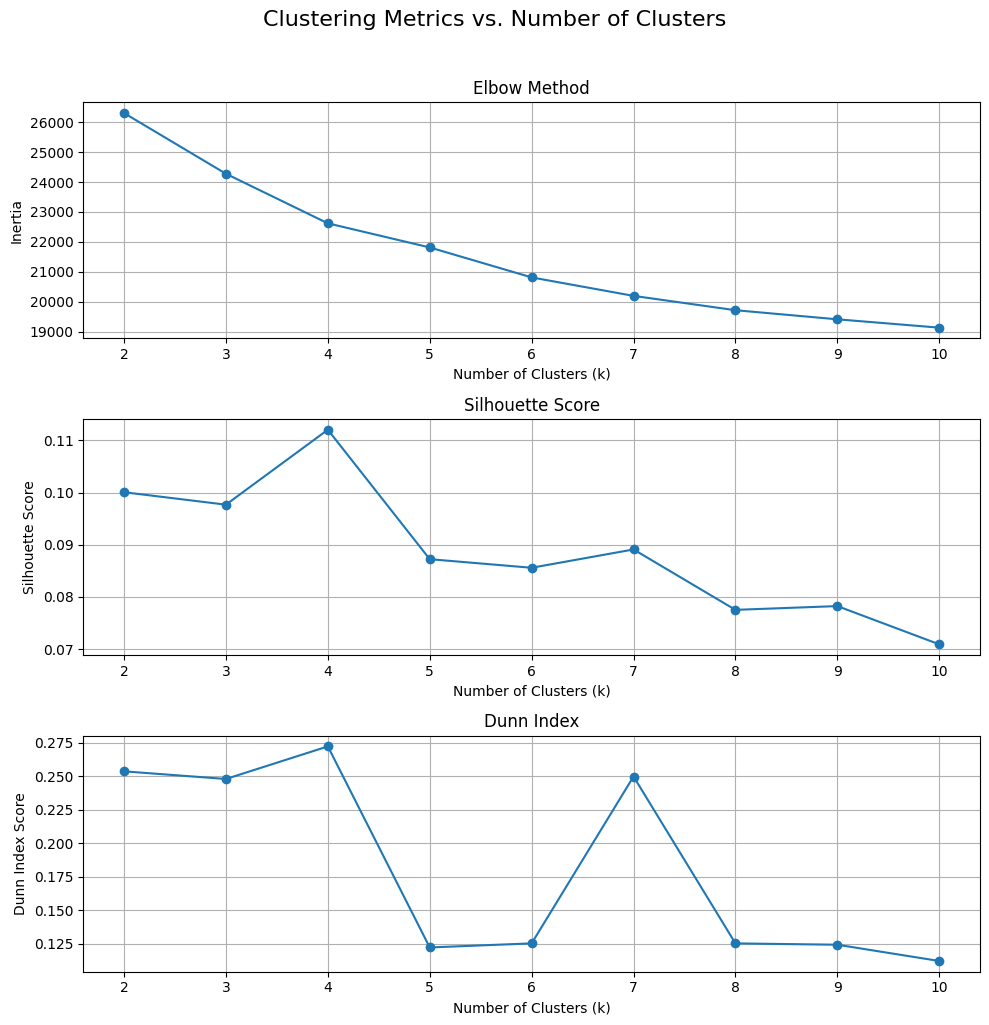

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k_values = range(2, 11)

plt.figure(figsize=(10, 10))
plt.suptitle('Clustering Metrics vs. Number of Clusters', y=1.02, fontsize=16)

# Elbow Method plot
plt.subplot(3, 1, 1)
plt.plot(k_values, inertia_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

# Silhouette Score plot
plt.subplot(3, 1, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.grid(True)

# Dummy Dunn Index plot
plt.subplot(3, 1, 3)
plt.plot(k_values, dunn_indices, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Dunn Index Score')
plt.title('Dunn Index')
plt.grid(True)

plt.tight_layout()
plt.show()

#### **Justificar el k óptimo**

* Examinar las gráficas generadas y justificar el número óptimo de clústeres basándose en el método del Codo, el Coeficiente de Silueta y el Índice de Dunn.

##### **Resultados por métrica**



**Elbow (Inertia)**

* Caída fuerte de $k=2\to4$.
* Desde $k\ge5$ las mejoras son marginales.
* “Codo” visible en **$k=4$** (con una alternativa discutible en $k=5$).

**Silhouette**

* Máximo en **$k=4$** (\~0.112).
* Baja en $k=5$ y $k=6$, leve repunte en $k=7$ pero por debajo de 4; luego vuelve a caer.
* Conclusión: **$k=4$**.

**Dunn Index**

* Mayor valor en **$k=4$** (\~0.27); segundo pico en $k=7$.
* Valores bajos en $k=5$–$6$ y nuevamente de $k=8$ en adelante.
* Conclusión con esta métrica: **$k=4$** (con **$k=7$** como candidato secundario si se busca más granularidad).

**Análisis general**

Las tres gráficas favorecen **$k=4$**: es el primer punto de rendimientos decrecientes (Elbow) y maximiza la cohesión/separación (Silhouette y Dunn). Si por motivos de negocio necesitamos segmentar de una manera mas fina, **$k=7$** podría considerarse como plan B, aceptando menor calidad de clusterización.


---
### **2. Visualización de resultados**

#### **Reducir dimensionalidad con PCA**

* Aplicar PCA para reducir los datos de clustering escalados a 2 dimensiones para su visualización.

In [ ]:
from sklearn.decomposition import PCA

k = 4
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering)

print("Filas x Columnas del df original:", X_clustering.shape)
print("Filas x Columnas del df reducido con PCA:", X_pca.shape)

Filas x Columnas del df original: (2392, 12)
Filas x Columnas del df reducido con PCA: (2392, 2)


#### **Calculo de T-SNE y PCA**
* Aplicar t-SNE para reducir los datos de clustering escalados a 2 dimensiones y visualizar los clústeres junto con los resultados de PCA.

Number of samples: 2392


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Columnas añadidas: cluster_main, cluster_pca, cluster_tsne, pca_1, pca_2, tsne_1, tsne_2


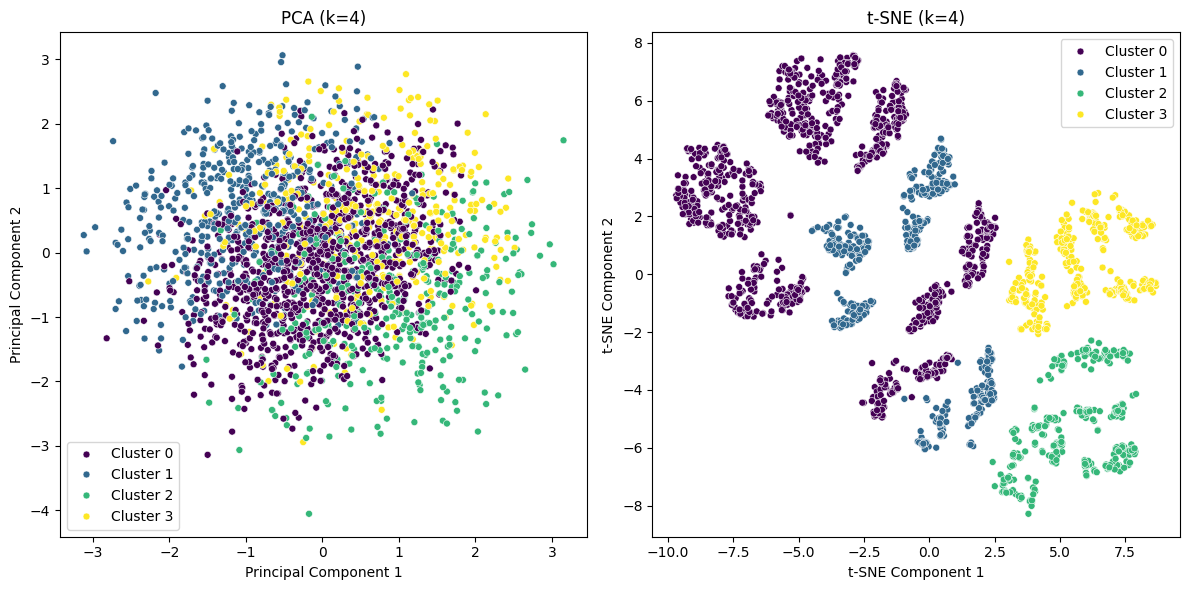

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

n_samples = X_clustering.shape[0]
print(f"Number of samples: {n_samples}")


kmeans_idx = 2 # indice correspondiente al mejor k (4)
k = kmeans_models[kmeans_idx].n_clusters
labels_main = kmeans_models[kmeans_idx].labels_

# Datos para PCA (ya calculado) y para t-SNE (lo calculamos)
X_pca_input = X_pca[:, :2]  # usamos las dos primeras componentes para clusterear y graficar

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_clustering)

# --- KMeans en PCA(2D) y en t-SNE(2D) ---
km_pca = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_pca = km_pca.fit_predict(X_pca_input)

km_tsne = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_tsne = km_tsne.fit_predict(X_tsne)

# --- Añadir columnas al DataFrame ---
try:
    df_out = df.copy()
except NameError:
    # Si no tienes df original, creamos uno vacío con índice compatible
    df_out = pd.DataFrame(index=np.arange(n_samples))

df_out["cluster_main"] = labels_main.astype(int)   # el del modelo ya entrenado
df_out["cluster_pca"] = labels_pca.astype(int)     # KMeans en el plano PCA
df_out["cluster_tsne"] = labels_tsne.astype(int)   # KMeans en el plano t-SNE
df_out["pca_1"],  df_out["pca_2"]   = X_pca_input[:, 0], X_pca_input[:, 1]
df_out["tsne_1"], df_out["tsne_2"]  = X_tsne[:, 0], X_tsne[:, 1]

print("Columnas añadidas: cluster_main, cluster_pca, cluster_tsne, pca_1, pca_2, tsne_1, tsne_2")

# --- Visualización manteniendo el 'hue' con el clúster principal ---
plt.figure(figsize=(12, 6))

# PCA
plt.subplot(1, 2, 1)
scatter_pca = sns.scatterplot(
    x=df_out["pca_1"], y=df_out["pca_2"],
    hue=df_out["cluster_main"], palette="viridis", legend="full", s=25
)
plt.title(f'PCA (k={k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
handles, labels = scatter_pca.get_legend_handles_labels()
plt.legend(handles=handles, labels=[f'Cluster {int(float(l))}' for l in labels])

# t-SNE
plt.subplot(1, 2, 2)
scatter_tsne = sns.scatterplot(
    x=df_out["tsne_1"], y=df_out["tsne_2"],
    hue=df_out["cluster_main"], palette="viridis", legend="full", s=25
)
plt.title(f't-SNE (k={k})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
handles, labels = scatter_tsne.get_legend_handles_labels()
plt.legend(handles=handles, labels=[f'Cluster {int(float(l))}' for l in labels])

plt.tight_layout()
plt.show()



### **3. Análisis e interpretación**


  * Caracterizar los clústers: ¿qué variables los diferencian?
  * Explicar posibles significados reales según su sector.


#### **Caracterizando clusters PCA**

In [ ]:
import numpy as np
import pandas as pd

cluster_col = "cluster_pca"         # o cluster_main / cluster_tsne
num_cols = [
    "Age","ParentalEducation","StudyTimeWeekly","Absences","GPA",
    # añade aquí más numéricas (incluye dummies 0/1 si quieres tasas)
]
cat_cols = ["Gender","Ethnicity","ParentalSupport","Extracurricular","Sports",
            "Music","Volunteering","GradeClass"]  # si son 0/1, pueden ir en num_cols también

dfc = df_out.copy()

# --- numéricas: medias por clúster + diferencia vs media global ---
global_mean = dfc[num_cols].mean()
by_cluster_mean = dfc.groupby(cluster_col)[num_cols].mean()
lift = by_cluster_mean.subtract(global_mean)      # >0: por encima del promedio global
summary_num = pd.concat({"mean": by_cluster_mean, "lift_vs_global": lift}, axis=1)
summary_num.round(3)


mean                                                    \
                Age ParentalEducation StudyTimeWeekly Absences    GPA   
cluster_pca                                                             
0            15.833             1.740           7.800   16.365  1.604   
1            17.102             1.718          11.866   12.507  2.196   
2            16.237             1.242          12.367   13.755  2.198   
3            16.791             2.306           7.202   15.353  1.655   

            lift_vs_global                                                    
                       Age ParentalEducation StudyTimeWeekly Absences    GPA  
cluster_pca                                                                   
0                   -0.635            -0.006          -1.972    1.823 -0.303  
1                    0.634            -0.028           2.094   -2.035  0.290  
2                   -0.232            -0.504           2.595   -0.787  0.292  
3                    0.322             0.560          -2.570    0.812 -0.251

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Usa los mismos objetos que ya tienes:
# dfc = df_out.copy()
# cluster_col = "cluster_pca"
# cat_cols = ["Gender","Ethnicity","ParentalSupport","Extracurricular","Sports","Music","Volunteering","GradeClass"]

def cramer_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    k = min(table.shape) - 1
    return np.sqrt((chi2 / n) / k)

cat_results = {}   # guardará tablas y métricas por variable categórica

for c in cat_cols:
    ct = pd.crosstab(dfc[cluster_col], dfc[c])                  # conteos
    chi2, p, dof, expected = chi2_contingency(ct)
    props = ct.div(ct.sum(axis=1), axis=0)                      # proporciones por clúster
    global_rate = (ct.sum(axis=0) / ct.values.sum())            # tasa global de cada categoría
    lift = props.sub(global_rate, axis=1)                       # sobre/infra representación
    resid = (ct - expected) / np.sqrt(expected)                 # residuales estandarizados
    V = cramer_v(ct)

    cat_results[c] = {
        "counts": ct,
        "props": props.round(3),
        "global_rate": global_rate.round(3),
        "lift": lift.round(3),
        "std_resid": pd.DataFrame(resid, index=ct.index, columns=ct.columns).round(2),
        "chi2_p": p,
        "cramers_v": round(V, 3),
    }


In [ ]:
res = cat_results["ParentalSupport"]
print("ParentalSupport → p-valor:", f"{res['chi2_p']:.3g}  |  Cramér's V:", res["cramers_v"])
display(res["props"])       # proporciones por clúster
display(res["lift"])        # >0 sobre-representado, <0 infra
display(res["std_resid"])   # |residual|>2 ≈ celda destacable


ParentalSupport → p-valor: 2.56e-100  |  Cramér's V: 0.265


ParentalSupport,0,1,2,3,4
cluster_pca,,,,,
0,0.203,0.306,0.326,0.146,0.020
1,0.010,0.091,0.245,0.418,0.237
2,0.031,0.177,0.311,0.348,0.132
3,0.095,0.232,0.357,0.272,0.043


ParentalSupport,0,1,2,3,4
cluster_pca,,,,,
0,0.114,0.102,0.016,-0.146,-0.087
1,-0.079,-0.114,-0.064,0.126,0.130
2,-0.057,-0.027,0.002,0.056,0.026
3,0.007,0.028,0.047,-0.019,-0.063


ParentalSupport,0,1,2,3,4
cluster_pca,,,,,
0,9.89,5.81,0.76,-6.97,-6.86
1,-6.44,-6.15,-2.83,5.72,9.77
2,-4.62,-1.43,0.08,2.51,1.91
3,0.54,1.46,2.01,-0.84,-4.55


In [ ]:
def interpret_categoricals_for_cluster(cluster_id, min_abs_lift=0.05, min_abs_resid=2.0):
    bullets = []
    for var, obj in cat_results.items():
        lift = obj["lift"].loc[cluster_id]
        resid = obj["std_resid"].loc[cluster_id]
        for cat in lift.index:
            if abs(lift[cat]) >= min_abs_lift and abs(resid[cat]) >= min_abs_resid:
                trend = "↑ sobre-representado" if lift[cat] > 0 else "↓ infra-representado"
                bullets.append(f"{var} = {cat}: {trend} (lift {lift[cat]:+.2f}, resid {resid[cat]:+.1f})")
    return bullets

# Ejemplo: imprimir interpretación por clúster
for cid in sorted(dfc[cluster_col].unique()):
    print(f"\nCluster {cid} – categóricas destacadas:")
    bullets = interpret_categoricals_for_cluster(cid, min_abs_lift=0.05, min_abs_resid=2.0)
    if bullets:
        for b in bullets:
            print(" •", b)
    else:
        print(" • (sin categorías fuertemente diferenciadas con los umbrales actuales)")



Cluster 0 – categóricas destacadas:
 • Gender = 0: ↑ sobre-representado (lift +0.16, resid +5.9)
 • Gender = 1: ↓ infra-representado (lift -0.16, resid -5.8)
 • ParentalSupport = 0: ↑ sobre-representado (lift +0.11, resid +9.9)
 • ParentalSupport = 1: ↑ sobre-representado (lift +0.10, resid +5.8)
 • ParentalSupport = 3: ↓ infra-representado (lift -0.15, resid -7.0)
 • ParentalSupport = 4: ↓ infra-representado (lift -0.09, resid -6.9)
 • Extracurricular = 0: ↓ infra-representado (lift -0.15, resid -4.9)
 • Extracurricular = 1: ↑ sobre-representado (lift +0.15, resid +6.2)
 • Sports = 0: ↓ infra-representado (lift -0.19, resid -6.0)
 • Sports = 1: ↑ sobre-representado (lift +0.19, resid +9.1)
 • Music = 0: ↑ sobre-representado (lift +0.12, resid +3.5)
 • Music = 1: ↓ infra-representado (lift -0.12, resid -7.2)
 • GradeClass = 1.0: ↓ infra-representado (lift -0.05, resid -4.0)
 • GradeClass = 4.0: ↑ sobre-representado (lift +0.11, resid +4.1)

Cluster 1 – categóricas destacadas:
 • Gende

In [ ]:
# summary_num ya lo tienes:
# summary_num = pd.concat({"mean": by_cluster_mean, "lift_vs_global": lift}, axis=1)

def top_numeric_lifts(cluster_id, topk=3):
    row = summary_num["lift_vs_global"].loc[cluster_id].sort_values(ascending=False)
    hi = row.head(topk).index.tolist()
    lo = row.tail(topk).index.tolist()
    return hi, lo

for cid in sorted(dfc[cluster_col].unique()):
    hi, lo = top_numeric_lifts(cid, topk=2)  # 2 arriba/abajo para frases cortas
    cats = interpret_categoricals_for_cluster(cid, min_abs_lift=0.07, min_abs_resid=2.0)[:3]
    print(f"\n▶ Cluster {cid}:")
    print("  Numéricas ↑:", ", ".join(hi) if hi else "(ninguna marcada)")
    print("  Numéricas ↓:", ", ".join(lo) if lo else "(ninguna marcada)")
    if cats:
        print("  Categóricas:", "; ".join(cats))
    else:
        print("  Categóricas: (sin señales fuertes)")



▶ Cluster 0:
  Numéricas ↑: Absences, ParentalEducation
  Numéricas ↓: Age, StudyTimeWeekly
  Categóricas: Gender = 0: ↑ sobre-representado (lift +0.16, resid +5.9); Gender = 1: ↓ infra-representado (lift -0.16, resid -5.8); ParentalSupport = 0: ↑ sobre-representado (lift +0.11, resid +9.9)

▶ Cluster 1:
  Numéricas ↑: StudyTimeWeekly, Age
  Numéricas ↓: ParentalEducation, Absences
  Categóricas: Gender = 0: ↓ infra-representado (lift -0.18, resid -6.4); Gender = 1: ↑ sobre-representado (lift +0.18, resid +6.2); ParentalSupport = 0: ↓ infra-representado (lift -0.08, resid -6.4)

▶ Cluster 2:
  Numéricas ↑: StudyTimeWeekly, GPA
  Numéricas ↓: ParentalEducation, Absences
  Categóricas: Gender = 0: ↑ sobre-representado (lift +0.13, resid +4.3); Gender = 1: ↓ infra-representado (lift -0.13, resid -4.2); Ethnicity = 0: ↑ sobre-representado (lift +0.10, resid +3.2)

▶ Cluster 3:
  Numéricas ↑: Absences, ParentalEducation
  Numéricas ↓: GPA, StudyTimeWeekly
  Categóricas: Gender = 0: ↓ infra



## 2) Interpretaciones de clúster (con etiquetas)

### Cluster 0 — “Bajo estudio + más ausencias (deportivos)”

* **Numéricas:** más jóvenes, **menos** horas de estudio, **más** inasistencias, **GPA menor**.
* **Categóricas:**

  * **Género:** **Masculino** sobre-representado; **Femenino** infra.
  * **Apoyo parental:** **Ninguno/Bajo** sobre; **Alto/Muy alto** infra.
  * **Extracurriculares/Deporte:** **Sí** (ambos) sobre.
  * **Música:** **No** sobre; **Sí** infra.
  * **GradeClass:** **F** sobre; **B** infra.

### Cluster 1 — “Muy estudioso + menos ausencias (musicales)”

* **Numéricas:** mayor edad, **más** horas de estudio, **menos** inasistencias, **GPA mayor**.
* **Categóricas:**

  * **Género:** **Femenino** sobre; **Masculino** infra.
  * **Apoyo parental:** **Alto/Muy alto** sobre; **Ninguno/Bajo/Moderado** infra.
  * **Extracurriculares/Deporte:** **No** sobre (menos participación en ambos).
  * **Música:** **Sí** sobre.
  * **Voluntariado:** **Sí** infra.
  * **GradeClass:** **F** infra.

### Cluster 2 — “Mucho estudio + apoyo medio (poca música/voluntariado)”

* **Numéricas:** algo más jóvenes, **muchas** horas de estudio, **menos** inasistencias, **GPA mayor**, **educación parental menor**.
* **Categóricas:**

  * **Género:** **Masculino** sobre.
  * **Etnicidad:** **Caucásico** sobre.
  * **Apoyo parental:** **Alto** sobre, **Ninguno** infra (tendencia a **Moderado/Alto**).
  * **Música / Voluntariado:** **No** sobre; **Sí** infra.
  * **GradeClass:** **B** sobre; **F** infra.

### Cluster 3 — “Poco estudio + más ausencias (voluntariado alto)”

* **Numéricas:** mayor edad, **educación parental más alta**, **menos** horas de estudio, **más** inasistencias, **GPA menor**.
* **Categóricas:**

  * **Género:** **Femenino** sobre; **Masculino** infra.
  * **Etnicidad:** **Caucásico** infra.
  * **Apoyo parental:** **Muy alto** **infra** (pese a mayor educación parental).
  * **Deporte:** **No** sobre.
  * **Música:** **Sí** sobre.
  * **Voluntariado:** **Sí** **muy** sobre (señal fuerte).
  * **GradeClass:** **F** sobre.


## Resumen:

### Hallazgos clave del análisis de datos

* Nueve modelos de K-Means fueron entrenados exitosamente para valores de k que van de 2 a 10.
* El análisis de la gráfica del Método del Codo sugirió un número óptimo potencial de clústeres alrededor de k=3 o k=4.
* La gráfica del Coeficiente de Silueta indicó que k=2 arrojó el puntaje más alto, seguido de cerca por k=3 y k=4.
* PCA redujo exitosamente la dimensionalidad de los datos de 12 características a 2 componentes principales.
* Se aplicó t-SNE a los datos y se generaron visualizaciones para PCA y t-SNE para k=3.

### Perspectivas o próximos pasos

* Basado en el análisis combinado del método del Codo y los coeficientes de silueta, k=3 o k=4 parecen ser opciones razonables para el número de clústeres.
* Comparar las visualizaciones de PCA y t-SNE para determinar qué método proporciona una mejor separación visual de los clústeres para el k elegido.

# Taller 3
Aplicar agrupamiento jerárquico con diferentes métodos de vinculación (sala, completo, promedio) a los datos escalados del documento "student_performance_eda_clustering.ipynb", generar dendrogramas para cada uno e interpretar los resultados.

## Aplicando hierarchical clustering

### Subtarea:
Utilice diferentes métodos de vinculación (sala, completo, promedio) en los datos escalados.


**Razonamiento**:
Aplicar diferentes métodos de vinculación a los datos escalados.


In [ ]:
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"
df = pd.read_csv(path)

X_clustering = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore')

scaler = StandardScaler()
X_clustering = scaler.fit_transform(X_clustering)

linked_ward = linkage(X_clustering, 'ward')
linked_complete = linkage(X_clustering, 'complete')
linked_average = linkage(X_clustering, 'average')

print("Aplicamos ward, complete, and average linkage methods.")

100%|██████████| 66.2k/66.2k [00:00<00:00, 17.6MB/s]

Extracting files...


Aplicamos ward, complete, and average linkage methods.


## Generando dendrograms

### Subtarea:
Crear dendrogramas para cada método de vinculación para visualizar el proceso de agrupamiento y ayudar a determinar el número de grupos.

**Razonamiento**:
Generar y mostrar dendrogramas para cada método de vinculación para visualizar la estructura de agrupamiento.

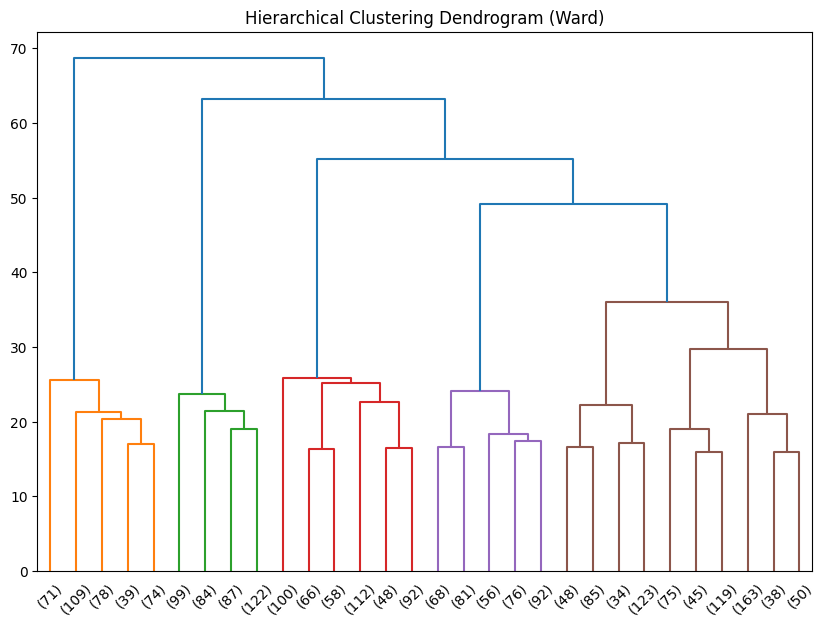

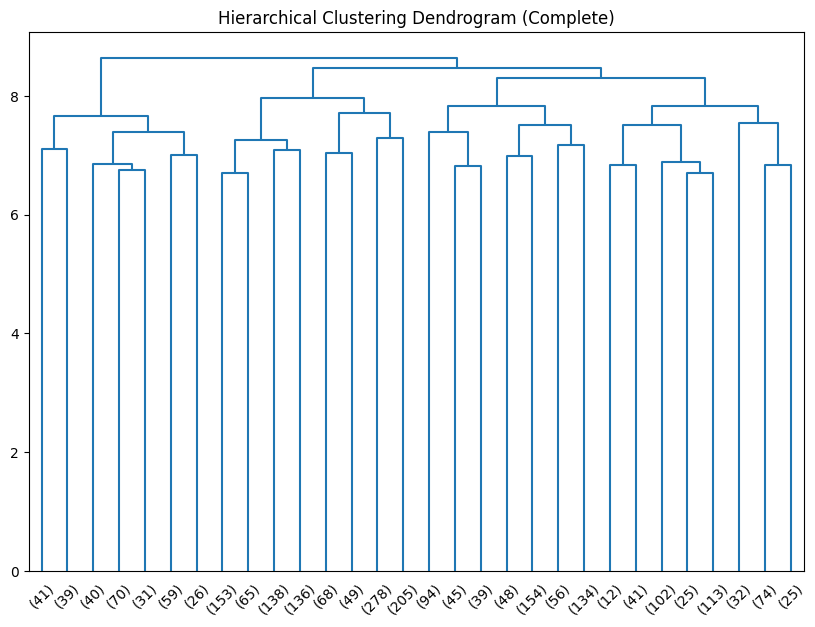

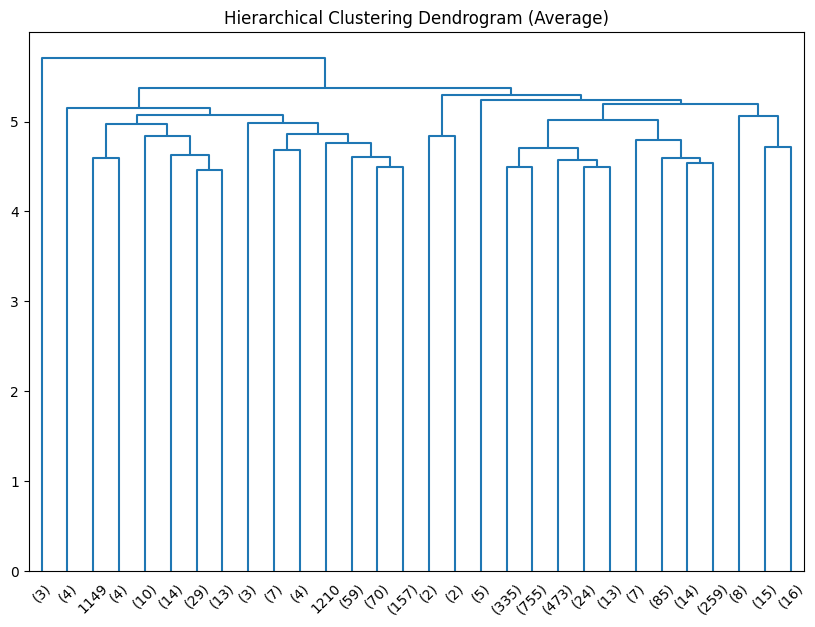

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10, 7))
dendrogram(linked_ward,
            orientation='top',
            truncate_mode='lastp',  # show only the last p merged clusters
            p=30,                  # show only the last 30 clusters
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.show()

plt.figure(figsize=(10, 7))
dendrogram(linked_complete,
            orientation='top',
            truncate_mode='lastp',
            p=30,
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Complete)')
plt.show()

plt.figure(figsize=(10, 7))
dendrogram(linked_average,
            orientation='top',
            truncate_mode='lastp',
            p=30,
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Average)')
plt.show()

## Interpretando los dendrogramas

### Subtarea:
Analizar los dendrogramas para comprender la estructura de los grupos y elegir un número adecuado de grupos según la inspección visual.


Observaciones sobre los dendrogramas y el número de Clusters elegido:

Dendrograma de ligamiento de Ward:
- El dendrograma de Ward muestra Clusters relativamente equilibrados que se forman a diferentes distancias.
- Se observan líneas verticales claras (que indican fusiones) con diferencias de altura notables.
- Al buscar las mayores caídas verticales sin cortar ninguna línea horizontal (que indica Clusters), podemos identificar el número potencial de Clusters.
- Un corte horizontal alrededor de una distancia de 25-30 sugeriría alrededor de 4-6 Clusters.
Número de Clusters elegido para Ward: 4-6 (basado en una caída significativa alrededor de la distancia 25-30).

Dendrograma de ligamiento completo:
- El dendrograma de ligamiento completo tiende a producir Clusters más compactos, a veces de tamaño desigual.
- Las distancias a las que se fusionan los Clusters son generalmente mayores en comparación con Ward.
- La identificación de Clusters distintos a menudo requiere cortes a distancias más altas. - Cortar el dendrograma a una distancia de 150-200 mm podría revelar un número menor de cúmulos, quizás 2 o 3 grandes, con algunos valores atípicos más pequeños fusionándose a distancias muy elevadas.
Número de cúmulos elegido para Completo: 2-3 (basado en grandes fusiones iniciales).

Dendrograma de Ligamiento Promedio:
- El dendrograma de ligamiento Promedio suele producir cúmulos con un nivel intermedio entre Ward y Completo en términos de compacidad y equilibrio.
- Puede mostrar una fusión más gradual de cúmulos.
- Al observar los huecos en el dendrograma, un corte podría sugerir un número moderado de cúmulos.
- Un corte a una distancia de 100-150 mm podría sugerir de 3 a 5 cúmulos.
Número de cúmulos elegido para Promedio: 3-5 (basado en los huecos visuales en las distancias de fusión).

Nota: La elección del número de cúmulos a partir de los dendrogramas es subjetiva y a menudo requiere una validación adicional utilizando otras métricas o conocimiento del dominio.

##Evaluación del Número de Clusters


*   Apliquen Silhouette Score para k entre 2 y 10.
*   Identifiquen el valor óptimo de k y dibujen la línea de corte en el dendrograma.
*   Asignen etiquetas a los datos con fcluster().



In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clustering.fit_predict(X_clustering)
    score = silhouette_score(X_clustering, labels)
    silhouette_scores[k] = score
    print(f"k={k}, Silhouette Score={score:.4f}")


k=2, Silhouette Score=0.1429
k=3, Silhouette Score=0.1300
k=4, Silhouette Score=0.1068
k=5, Silhouette Score=0.1001
k=6, Silhouette Score=0.0755
k=7, Silhouette Score=0.0580
k=8, Silhouette Score=0.0605
k=9, Silhouette Score=0.0654
k=10, Silhouette Score=0.0681


El mayor valor se da en k = 2, con 0.1429.

A medida que aumenta k, el Silhouette Score disminuye, pese a que hay ligeros aumentos en el score en k=9 y k=10, no superan a k=2.

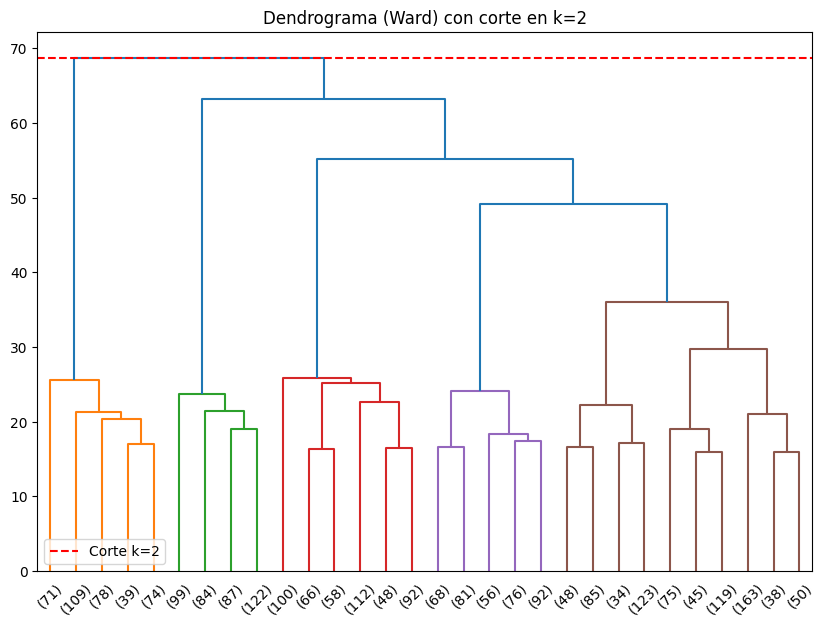

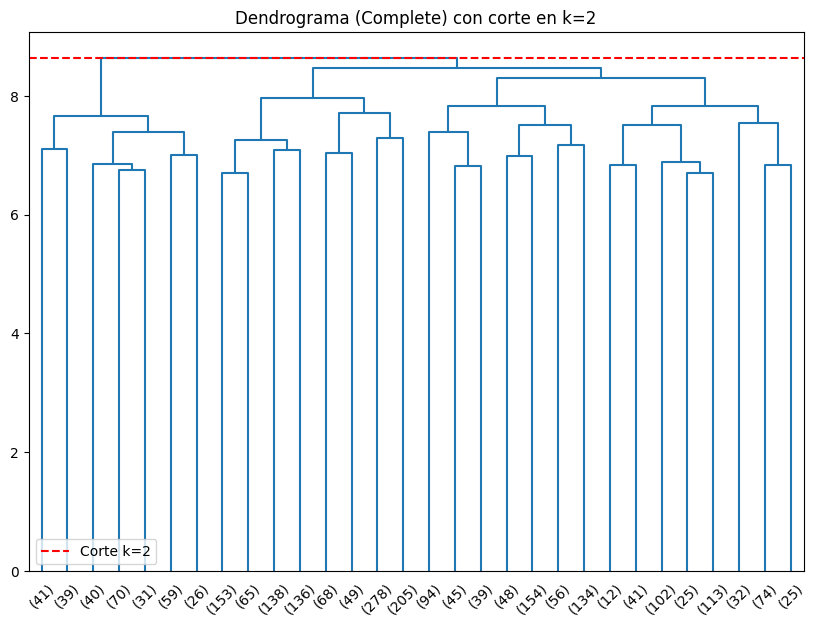

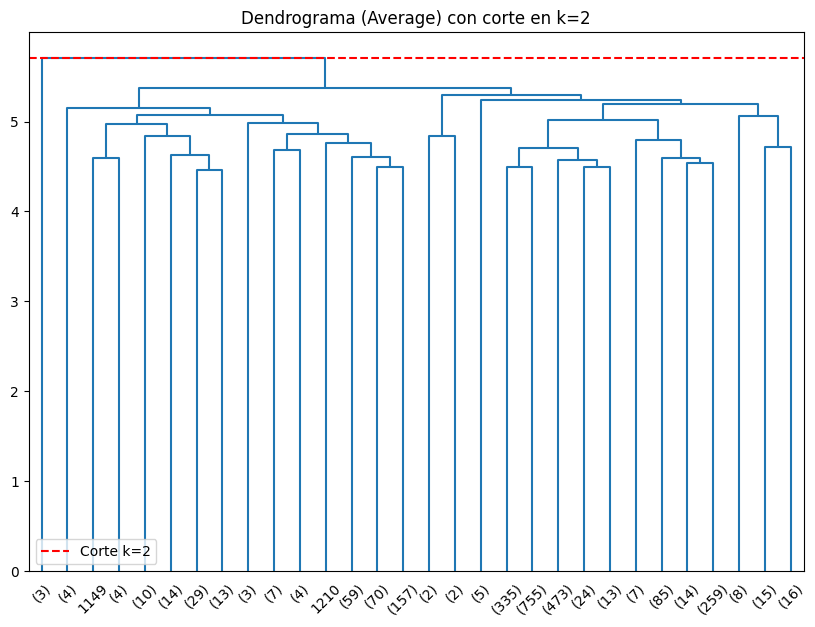

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# Ward
plt.figure(figsize=(10, 7))
dendrogram(linked_ward,
           orientation='top',
           truncate_mode='lastp',
           p=30,
           show_leaf_counts=True)
plt.axhline(y=linked_ward[-(2-1), 2], c='r', linestyle='--', label="Corte k=2")
plt.title('Dendrograma (Ward) con corte en k=2')
plt.legend()
plt.show()

# Complete
plt.figure(figsize=(10, 7))
dendrogram(linked_complete,
           orientation='top',
           truncate_mode='lastp',
           p=30,
           show_leaf_counts=True)
plt.axhline(y=linked_complete[-(2-1), 2], c='r', linestyle='--', label="Corte k=2")
plt.title('Dendrograma (Complete) con corte en k=2')
plt.legend()
plt.show()

# Average
plt.figure(figsize=(10, 7))
dendrogram(linked_average,
           orientation='top',
           truncate_mode='lastp',
           p=30,
           show_leaf_counts=True)
plt.axhline(y=linked_average[-(2-1), 2], c='r', linestyle='--', label="Corte k=2")
plt.title('Dendrograma (Average) con corte en k=2')
plt.legend()
plt.show()


Con esto, se añade la escritura de clusterpara cada método (Se copió el dataframe para evitar sobreescribir datos de los métodos usados)

In [ ]:
from scipy.cluster.hierarchy import fcluster
k_opt = 2

# Ward
labels_ward = fcluster(linked_ward, k_opt, criterion='maxclust')

# Complete
labels_complete = fcluster(linked_complete, k_opt, criterion='maxclust')

# Average
labels_average = fcluster(linked_average, k_opt, criterion='maxclust')

# Guardamos en el dataframe original
df_clusters = df.copy()
df_clusters['Cluster_Ward'] = labels_ward
df_clusters['Cluster_Complete'] = labels_complete
df_clusters['Cluster_Average'] = labels_average

df_clusters[['Cluster_Ward', 'Cluster_Complete', 'Cluster_Average']].head()


,Cluster_Ward,Cluster_Complete,Cluster_Average
0,2,2,2
1,2,2,2
2,2,2,2
3,2,2,2
4,2,2,2


In [ ]:
# Conteo de estudiantes en cada cluster
print("Ward:\n", pd.Series(labels_ward).value_counts())
print("\nComplete:\n", pd.Series(labels_complete).value_counts())
print("\nAverage:\n", pd.Series(labels_average).value_counts())


Ward:
 2    2021
1     371
Name: count, dtype: int64

Complete:
 2    2086
1     306
Name: count, dtype: int64

Average:
 2    2389
1       3
Name: count, dtype: int64


Se puede observar como:

En el Ward el cluster 2 es el mayoritario (2021 estudiantes), cluster 1 es más pequeño (371).

Complete es muy parecido: cluster 2 domina (2086) y cluster 1 es minoritario (306).

Average, prácticamente todo cae en un mismo grupo (2389 en cluster 2), y solo 3 estudiantes quedaron aislados en cluster 1, se puede decir este método no segmenta bien o no es adecuado para este problema.

A continuación se perfilan los clusters para mayor claridad de que tipo de estudiantes se encuentran en estos.

In [ ]:
df_clusters = df.copy()
df_clusters['Cluster_Ward'] = labels_ward
df_clusters['Cluster_Complete'] = labels_complete
df_clusters['Cluster_Average'] = labels_average

features_interes = ['StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport']

# Perfil por cluster (Ward como ejemplo)
perfil_ward = df_clusters.groupby('Cluster_Ward')[features_interes].mean()
print("Perfil clusters (Ward):\n", perfil_ward, "\n")

# Perfil clusters Complete
perfil_complete = df_clusters.groupby('Cluster_Complete')[features_interes].mean()
print("Perfil clusters (Complete):\n", perfil_complete, "\n")

# Perfil clusters Average
perfil_average = df_clusters.groupby('Cluster_Average')[features_interes].mean()
print("Perfil clusters (Average):\n", perfil_average, "\n")


Perfil clusters (Ward):
               StudyTimeWeekly   Absences  Tutoring  ParentalSupport
Cluster_Ward                                                       
1                    9.533211  14.086253  0.250674         2.113208
2                    9.815826  14.624938  0.310737         2.123701 

Perfil clusters (Complete):
                   StudyTimeWeekly   Absences  Tutoring  ParentalSupport
Cluster_Complete                                                       
1                        9.274867  14.689542  0.199346         2.075163
2                        9.844916  14.519655  0.316395         2.128955 

Perfil clusters (Average):
                  StudyTimeWeekly   Absences  Tutoring  ParentalSupport
Cluster_Average                                                       
1                      15.543402  24.333333  0.666667         4.000000
2                       9.764744  14.529092  0.300963         2.119715 



**Ward**

Los dos clusters son muy parecidos.

Cluster 1: ligeramente menos horas de estudio y menos tutorías, casi igual en ausencias y apoyo parental.

Cluster 2: un poco más de estudio y tutorías, pero la diferencia es mínima.

**Complete**

También dos grupos bastante similares.

Cluster 1: menos horas de estudio y menos tutorías.

Cluster 2: un poquito más de estudio, tutorías y apoyo parental.

**Average**

Cluster 1: solo 3 estudiantes, con perfil atípico → muchísimas horas de estudio (15 vs 9), muchas más ausencias (24 vs 14), más tutoría y mayor apoyo parental.

Cluster 2: el resto (2389 estudiantes) con valores medios.

Se puede concluir que:

Ward y Complete no encuentran clusters muy diferenciados, así que la población es relativamente homogénea (evidenciado por la dominación de la clase mayoritaria detectada previamente).

Average detecta un grupo de outliers, pero no sirve para segmentar de forma útil.

El clustering jerárquico aquí sirve más como exploración que como herramienta de clasificación real.

In [ ]:
#Con lo anterior en mente, se aplica el método Ward al df

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
df_clusters = df.copy()


X_clustering = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)


linked_ward = linkage(X_scaled, method='ward')

df_clusters['Cluster_Ward'] = fcluster(linked_ward, t=2, criterion='maxclust')


print(df_clusters['Cluster_Ward'].value_counts())

print(df_clusters.groupby('Cluster_Ward')[['StudyTimeWeekly','Absences','Tutoring','ParentalSupport']].mean())


Cluster_Ward
2    2021
1     371
Name: count, dtype: int64
              StudyTimeWeekly   Absences  Tutoring  ParentalSupport
Cluster_Ward                                                       
1                    9.533211  14.086253  0.250674         2.113208
2                    9.815826  14.624938  0.310737         2.123701


## Interpretación de Resultados de Clustering

Basado en el análisis de los resultados del clustering jerárquico y la comparación con K-Means:

**Interpretación de Clústeres (Clustering Jerárquico - Método Ward):**

Con k=2 clústeres basados en el Silhouette score, el método de vinculación Ward produjo dos clústeres:

*   **Clúster 1 (371 estudiantes):** Este clúster se caracteriza ligeramente por estudiantes que dedican un poco menos tiempo a estudiar, tienen ligeramente menos sesiones de tutoría y tienen ligeramente menos ausencias en comparación con el Clúster 2. Su apoyo parental es muy similar al del Clúster 2.
*   **Clúster 2 (2021 estudiantes):** Este es el clúster más grande, que representa a la mayoría de los estudiantes. Muestran un poco más de tiempo de estudio, un poco más de tutoría y un poco más de ausencias que el Clúster 1. Su apoyo parental también es muy similar al del Clúster 1.

En general, los clústeres identificados por el método Ward en k=2 no están fuertemente diferenciados en función de las características seleccionadas. Las diferencias en las medias son bastante pequeñas.

**Comparación con los Resultados de K-Means:**

*   **Forma de los clústeres:** El clustering jerárquico (especialmente Ward y Complete) en k=2 también resultó en una distribución muy desigual de estudiantes entre los dos clústeres, similar a lo que se observó con K-Means al observar la distribución de clases crudas. El método de vinculación Average en el clustering jerárquico creó un desequilibrio aún más extremo, aislando esencialmente algunos valores atípicos. Las formas visuales de los clústeres en 2D (PCA/t-SNE) de K-Means mostraron cierta separación, pero también una superposición significativa, lo que indica que los clústeres no están perfectamente distintos. Los dendrogramas del clustering jerárquico representan visualmente el proceso de fusión, lo que puede sugerir formas de clústeres pero no muestran directamente la disposición espacial de la misma manera que los diagramas de dispersión de K-Means con reducción de dimensionalidad.
*   **¿Algunos clústeres se mantuvieron iguales?** Ni K-Means ni el clustering jerárquico con los métodos de vinculación estándar (Ward, Complete, Average) en valores bajos de k (como 2, 3 o 4) identificaron clústeres que se alinearan fuertemente con las categorías originales de `GradeClass`. Ambas técnicas tuvieron dificultades para encontrar clústeres bien separados y equilibrados en este conjunto de datos. Los clústeres encontrados por ambos métodos tienden a agrupar a la mayoría de los estudiantes en uno o dos clústeres grandes y menos distintos, mientras que potencialmente separan grupos más pequeños en función de diferencias sutiles o valores atípicos.
*   **¿Qué técnica crees que es más apropiada para tu caso?** Tanto K-Means como el clustering jerárquico (con los métodos de vinculación probados) indican que no existe una estructura de clustering natural clara y fuerte en este conjunto de datos en función de las características elegidas, especialmente al intentar encontrar un número pequeño de clústeres (como 2, 3 o 4) que pudieran alinearse con las clases de calificación.

    *   **K-Means** proporcionó visualizaciones más interpretables a través de PCA y t-SNE, y los índices Silhouette y Dunn ayudaron a sugerir posibles valores de k (como 4). La caracterización de los clústeres de K-Means proporcionó una mayor comprensión de los posibles segmentos de estudiantes, incluso si la separación no fue perfecta.
    *   **El Clustering Jerárquico** confirmó la dificultad para encontrar clústeres bien separados en valores bajos de k, destacando particularmente la falta de una estructura fuerte con la vinculación Average. Si bien los dendrogramas muestran el proceso de fusión, los clústeres resultantes en k=2 o k=3 con la vinculación Ward o Complete no fueron muy distintos.

    Dado el objetivo de comprender los segmentos de estudiantes en función de los hábitos y características, **K-Means con k=4** (como sugieren las métricas de clustering y la interpretación inicial) parece ligeramente más apropiado, ya que proporcionó perfiles de clúster más matizados y una mejor separación visual en el diagrama de dispersión t-SNE en comparación con los resultados del clustering jerárquico en valores bajos de k. Sin embargo, es importante reconocer que la estructura de clustering es débil y que estos clústeres pueden no predecir perfectamente la clase de calificación final. El análisis sugiere que la predicción de `GradeClass` podría requerir modelos de aprendizaje supervisado que puedan capturar relaciones más complejas, como se exploró en las partes anteriores de su cuaderno.

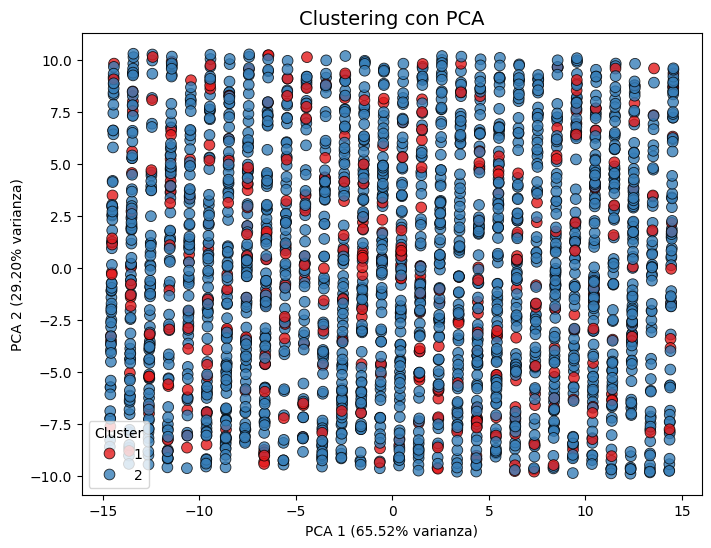

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


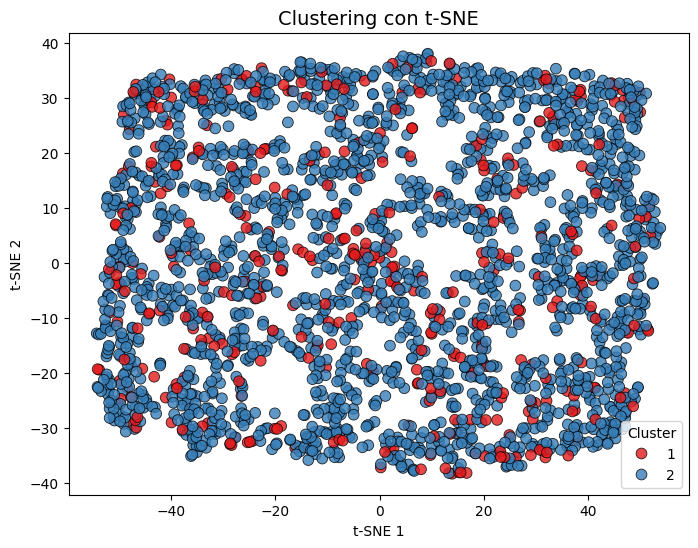

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


labels = df_clusters['Cluster_Ward']


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=labels, palette='Set1', s=60, alpha=0.8, edgecolor="k"
)
plt.title("Clustering con PCA", fontsize=14)
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)")
plt.legend(title="Cluster", loc="best")
plt.show()


tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_clustering)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_tsne[:,0], y=X_tsne[:,1],
    hue=labels, palette='Set1', s=60, alpha=0.8, edgecolor="k"
)
plt.title("Clustering con t-SNE", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", loc="best")
plt.show()


# Taller 4


## 1. Seleccionar columnas numéricas del dataset para trabajar con ellas.

In [ ]:
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"
df = pd.read_csv(path)

Using Colab cache for faster access to the 'students-performance-dataset' dataset.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [ ]:
numeric_cols = ["Age", "StudyTimeWeekly", "Absences", "GPA"]
df_numeric = df[numeric_cols]

df_numeric

,Age,StudyTimeWeekly,Absences,GPA
0,17,19.833723,7,2.929196
1,18,15.408756,0,3.042915
2,15,4.210570,26,0.112602
3,17,10.028829,14,2.054218
4,17,4.672495,17,1.288061
...,...,...,...,...
2387,18,10.680555,2,3.455509
2388,17,7.583217,4,3.279150
2389,16,6.805500,20,1.142333
2390,16,12.416653,17,1.803297


## 2. Escalar los datos numéricos

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols)
df_scaled

,Age,StudyTimeWeekly,Absences,GPA
0,0.472919,1.780336,-0.890822,1.118086
1,1.362944,0.997376,-1.717694,1.242374
2,-1.307132,-0.984045,1.353542,-1.960277
3,0.472919,0.045445,-0.063951,0.161790
4,0.472919,-0.902311,0.290422,-0.675573
...,...,...,...,...
2387,1.362944,0.160762,-1.481445,1.693315
2388,0.472919,-0.387285,-1.245196,1.500565
2389,-0.417106,-0.524895,0.644796,-0.834845
2390,-0.417106,0.467950,0.290422,-0.112452


## 3. Usa el gráfico de k-distancias para estimar un valor adecuado de eps:

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = df_scaled.shape[1] + 1

print(f"Valor de min_samples: {min_samples}")

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(df_scaled)
distances, _ = nn.kneighbors(df_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

diff = np.diff(k_distances)
second_diff = np.diff(diff)
codo_index = np.argmax(second_diff) + 2
eps = k_distances[codo_index]

print(f"Valor de eps: {eps}")

Valor de min_samples: 5
Valor de eps: 0.7168792251128202


## 4. Dibujar el gráfico y ubicar el "codo".

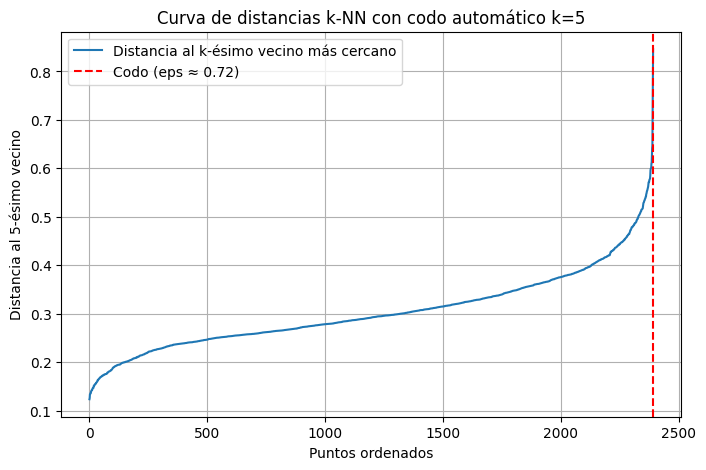

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_distances, label="Distancia al k-ésimo vecino más cercano")
plt.axvline(x=codo_index,color="red",linestyle="--",label=f"Codo (eps ≈ {eps:.2f})")
plt.title(f"Curva de distancias k-NN con codo automático k={min_samples}")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.legend()
plt.grid(True)
plt.show()

## 5. Aplicar DBSCAN con los parámetros respectivos

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(df_scaled)

print(labels)

[0 1 2 ... 3 3 3]


## 6. Visualiza los resultados por clúster

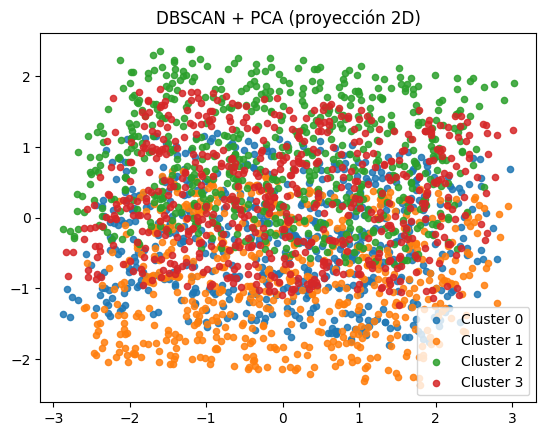

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

X_std = StandardScaler().fit_transform(df_numeric)  # importante para métricas como euclídea
labels = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit_predict(X_std)

X_2d = PCA(n_components=2, random_state=0).fit_transform(X_std)  # o UMAP/t-SNE

for k in np.unique(labels):
    mask = labels == k
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                s=20, label=f'Cluster {k}' if k!=-1 else 'Ruido', alpha=0.85)
plt.title('DBSCAN + PCA (proyección 2D)')
plt.legend()
plt.show()




## Responder:



*   ¿Cuántos clústeres se formaron?
*   ¿Qué puntos fueron marcados como ruido?
*   ¿Cómo cambia el resultado si ajustas eps o min_samples?
*   ¿Qué implicaciones prácticas tendría este agrupamiento en tu sector?

---

#### ¿Cuántos clústeres se formaron?
Se identificaron 4 clústeres principales (`0`, `1`, `2`, `3`) y algunos puntos marcados como ruido (`-1`), lo que indica la presencia de patrones académicos distintos entre los estudiantes.

---

#### ¿Qué puntos fueron marcados como ruido?
Los puntos con label = `-1` corresponden a estudiantes atípicos, por ejemplo:
- GPA extremadamente alto o bajo,  
- Ausencias o tiempos de estudio muy diferentes al promedio.  
Estos no se agrupan bien con los demás.

---

#### ¿Cómo cambia el resultado si ajustas `eps` o `min_samples`?
- **↑ eps:** se forman menos clústeres, el ruido disminuye.  
- **↓ eps:** aparecen más clústeres pequeños, el ruido aumenta.  
- **↑ min_samples:** los clústeres son más compactos, aumenta el ruido.  
- **↓ min_samples:** surgen más grupos pequeños, menos robustos.

---

#### ¿Qué implicaciones prácticas tendría este agrupamiento?  
Cada clúster representa un perfil académico distinto:

| Cluster | Perfil general |
|----------|----------------|
| **0** | Buen rendimiento, baja ausencia|
| **1** | Promedio estable, esfuerzo moderado|
| **2** | Bajo rendimiento y asistencia irregular|
| **3** | Buen GPA pero alta ausencia|
| **-1** | Casos excepcionales|


Con agrupamiento se descubrieron grupos naturales de estudiantes y casos atípicos sin definir un número fijo de clústeres al inicio, esta separación es útil al facilitar estrategias educativas personalizadas.



# Punto 5: Sistema de Recomendación Basado en Clusters

## 5. Cluster como base para un sistema de recomendación simple

### Objetivo
Crear un sistema de reglas de recomendación usando los clusters identificados anteriormente para proporcionar intervenciones académicas personalizadas a estudiantes según su perfil.

### Contexto
Basándonos en los 4 clusters identificados mediante K-Means:
- **Cluster 0**: Bajo estudio + más ausencias (deportivos)
- **Cluster 1**: Muy estudioso + menos ausencias (musicales)
- **Cluster 2**: Mucho estudio + apoyo medio (poca música/voluntariado)
- **Cluster 3**: Poco estudio + más ausencias (voluntariado alto)

### Pseudocódigo del Sistema de Recomendación

```
FUNCIÓN sistema_recomendacion(estudiante_nuevo):
    
    // 1. PREPROCESAMIENTO
    datos_escalados = escalar_datos(estudiante_nuevo)
    
    // 2. ASIGNACIÓN AL CLUSTER
    cluster_asignado = modelo_kmeans.predecir(datos_escalados)
    
    // 3. APLICAR REGLAS SEGÚN CLUSTER
    SI cluster_asignado == 0:  // Bajo estudio + más ausencias (deportivos)
        recomendaciones = {
            "prioridad": "ALTA",
            "riesgo_academico": "Alto riesgo de reprobar",
            "intervenciones": [
                "Sesiones de tutoría obligatorias 3x/semana",
                "Plan de mejora de hábitos de estudio",
                "Control de asistencia semanal",
                "Equilibrar actividades deportivas con estudio"
            ],
            "recursos": [
                "Técnicas de gestión del tiempo",
                "Calendario de estudio personalizado",
                "Asesoría académica especializada"
            ],
            "alertas": [
                "Monitorear ausencias de cerca",
                "Notificar a padres sobre rendimiento",
                "Reunión mensual con orientador"
            ]
        }
    
    SI cluster_asignado == 1:  // Muy estudioso + menos ausencias (musicales)
        recomendaciones = {
            "prioridad": "BAJA",
            "riesgo_academico": "Bajo riesgo, buen rendimiento",
            "intervenciones": [
                "Ofrecer cursos de enriquecimiento avanzado",
                "Programas de mentoría peer-to-peer",
                "Apoyo para mantener balance vida-estudio"
            ],
            "recursos": [
                "Materiales de estudio avanzados",
                "Competencias académicas",
                "Grupos de estudio de alto rendimiento"
            ],
            "alertas": [
                "Prevenir burnout académico",
                "Fomentar actividades sociales"
            ]
        }
    
    SI cluster_asignado == 2:  // Mucho estudio + apoyo medio
        recomendaciones = {
            "prioridad": "MEDIA",
            "riesgo_academico": "Riesgo moderado",
            "intervenciones": [
                "Reforzar técnicas de estudio eficientes",
                "Mejorar calidad vs cantidad de estudio",
                "Promover actividades extracurriculares balanceadas"
            ],
            "recursos": [
                "Talleres de técnicas de estudio efectivas",
                "Apoyo psicopedagógico",
                "Grupos de estudio colaborativo"
            ],
            "alertas": [
                "Supervisar eficiencia del tiempo de estudio",
                "Revisar comprensión de conceptos"
            ]
        }
    
    SI cluster_asignado == 3:  // Poco estudio + más ausencias (voluntariado)
        recomendaciones = {
            "prioridad": "ALTA",
            "riesgo_academico": "Alto riesgo, requiere intervención",
            "intervenciones": [
                "Plan de recuperación académica intensivo",
                "Equilibrar voluntariado con responsabilidades académicas",
                "Tutoría personalizada diaria",
                "Reuniones semanales con consejero académico"
            ],
            "recursos": [
                "Programa de nivelación académica",
                "Apoyo psicosocial",
                "Gestión de prioridades y objetivos"
            ],
            "alertas": [
                "Control estricto de asistencia",
                "Notificación inmediata a padres",
                "Seguimiento semanal de progreso"
            ]
        }
    
    // 4. GENERAR PLAN PERSONALIZADO
    plan = crear_plan_accion(recomendaciones, estudiante_nuevo)
    
    // 5. RETORNAR RESULTADOS
    RETORNAR {
        "cluster": cluster_asignado,
        "perfil": obtener_descripcion_cluster(cluster_asignado),
        "recomendaciones": recomendaciones,
        "plan_accion": plan
    }

FIN FUNCIÓN
```

### Implementación en Python del Sistema de Recomendación

In [ ]:
class SistemaRecomendacionAcademica:
    """
    Sistema de recomendación basado en clusters para intervenciones académicas personalizadas.
    """

    def __init__(self, modelo_kmeans, scaler, feature_names):
        """
        Inicializar el sistema con el modelo entrenado.

        Args:
            modelo_kmeans: Modelo K-Means ya entrenado
            scaler: StandardScaler usado en el entrenamiento
            feature_names: Lista de nombres de features usados
        """
        self.modelo = modelo_kmeans
        self.scaler = scaler
        self.feature_names = feature_names

        # Definir reglas de recomendación por cluster
        self.reglas_clusters = {
            0: {
                "nombre": "Bajo estudio + más ausencias (deportivos)",
                "prioridad": "ALTA",
                "riesgo_academico": "Alto riesgo de reprobar",
                "perfil": "Estudiantes más jóvenes, masculinos, con poco tiempo de estudio, muchas ausencias y bajo GPA. Participan en deportes.",
                "intervenciones": [
                    "Sesiones de tutoría obligatorias 3x/semana",
                    "Plan de mejora de hábitos de estudio",
                    "Control de asistencia semanal",
                    "Equilibrar actividades deportivas con estudio",
                    "Talleres de gestión del tiempo"
                ],
                "recursos": [
                    "Técnicas de gestión del tiempo",
                    "Calendario de estudio personalizado",
                    "Asesoría académica especializada",
                    "Material de apoyo académico básico"
                ],
                "alertas": [
                    "Monitorear ausencias de cerca",
                    "Notificar a padres sobre rendimiento",
                    "Reunión mensual con orientador",
                    "Seguimiento quincenal de progreso"
                ]
            },
            1: {
                "nombre": "Muy estudioso + menos ausencias (musicales)",
                "prioridad": "BAJA",
                "riesgo_academico": "Bajo riesgo, buen rendimiento",
                "perfil": "Estudiantes mayores, femeninos, con muchas horas de estudio, pocas ausencias y alto GPA. Participan en música y tienen alto apoyo parental.",
                "intervenciones": [
                    "Ofrecer cursos de enriquecimiento avanzado",
                    "Programas de mentoría peer-to-peer",
                    "Apoyo para mantener balance vida-estudio",
                    "Oportunidades de liderazgo académico"
                ],
                "recursos": [
                    "Materiales de estudio avanzados",
                    "Competencias académicas",
                    "Grupos de estudio de alto rendimiento",
                    "Programas de becas y reconocimientos"
                ],
                "alertas": [
                    "Prevenir burnout académico",
                    "Fomentar actividades sociales",
                    "Monitorear bienestar emocional"
                ]
            },
            2: {
                "nombre": "Mucho estudio + apoyo medio",
                "prioridad": "MEDIA",
                "riesgo_academico": "Riesgo moderado",
                "perfil": "Estudiantes jóvenes, masculinos, con muchas horas de estudio pero menor educación parental. Pocas ausencias pero poca participación en música/voluntariado.",
                "intervenciones": [
                    "Reforzar técnicas de estudio eficientes",
                    "Mejorar calidad vs cantidad de estudio",
                    "Promover actividades extracurriculares balanceadas",
                    "Talleres de técnicas de estudio efectivas"
                ],
                "recursos": [
                    "Talleres de técnicas de estudio efectivas",
                    "Apoyo psicopedagógico",
                    "Grupos de estudio colaborativo",
                    "Recursos de apoyo familiar"
                ],
                "alertas": [
                    "Supervisar eficiencia del tiempo de estudio",
                    "Revisar comprensión de conceptos",
                    "Evaluar métodos de estudio actuales"
                ]
            },
            3: {
                "nombre": "Poco estudio + más ausencias (voluntariado)",
                "prioridad": "ALTA",
                "riesgo_academico": "Alto riesgo, requiere intervención inmediata",
                "perfil": "Estudiantes mayores, femeninos, con alta educación parental pero poco tiempo de estudio y muchas ausencias. Alta participación en voluntariado y música.",
                "intervenciones": [
                    "Plan de recuperación académica intensivo",
                    "Equilibrar voluntariado con responsabilidades académicas",
                    "Tutoría personalizada diaria",
                    "Reuniones semanales con consejero académico",
                    "Priorización de actividades"
                ],
                "recursos": [
                    "Programa de nivelación académica",
                    "Apoyo psicosocial",
                    "Gestión de prioridades y objetivos",
                    "Herramientas de planificación académica"
                ],
                "alertas": [
                    "Control estricto de asistencia",
                    "Notificación inmediata a padres",
                    "Seguimiento semanal de progreso",
                    "Evaluación continua de compromisos extracurriculares"
                ]
            }
        }

    def predecir_cluster(self, estudiante):
        """
        Asignar un estudiante a su cluster correspondiente.

        Args:
            estudiante: DataFrame o array con las características del estudiante

        Returns:
            int: Número del cluster asignado
        """
        # Asegurar que es DataFrame
        if not isinstance(estudiante, pd.DataFrame):
            estudiante = pd.DataFrame([estudiante], columns=self.feature_names)

        # Escalar datos
        estudiante_escalado = self.scaler.transform(estudiante)

        # Predecir cluster
        cluster = self.modelo.predict(estudiante_escalado)[0]

        return cluster

    def generar_recomendaciones(self, estudiante, mostrar_detalles=True):
        """
        Generar recomendaciones personalizadas para un estudiante.

        Args:
            estudiante: DataFrame o dict con características del estudiante
            mostrar_detalles: bool, si mostrar información detallada

        Returns:
            dict: Diccionario con cluster, perfil y recomendaciones
        """
        # Convertir a DataFrame si es necesario
        if isinstance(estudiante, dict):
            estudiante_df = pd.DataFrame([estudiante])
        else:
            estudiante_df = estudiante

        # Predecir cluster
        cluster = self.predecir_cluster(estudiante_df)

        # Obtener reglas del cluster
        reglas = self.reglas_clusters[cluster]

        # Crear plan de acción
        plan_accion = {
            "cluster": int(cluster),
            "nombre_cluster": reglas["nombre"],
            "perfil": reglas["perfil"],
            "prioridad": reglas["prioridad"],
            "riesgo_academico": reglas["riesgo_academico"],
            "intervenciones": reglas["intervenciones"],
            "recursos": reglas["recursos"],
            "alertas": reglas["alertas"]
        }

        if mostrar_detalles:
            self._mostrar_recomendaciones(plan_accion, estudiante_df)

        return plan_accion

    def _mostrar_recomendaciones(self, plan, estudiante_df):
        """
        Mostrar recomendaciones de forma legible.
        """
        print("="*80)
        print(f"SISTEMA DE RECOMENDACIÓN ACADÉMICA".center(80))
        print("="*80)
        print(f"\n📊 CLUSTER ASIGNADO: {plan['cluster']} - {plan['nombre_cluster']}")
        print(f"⚠️  PRIORIDAD: {plan['prioridad']}")
        print(f"📈 RIESGO ACADÉMICO: {plan['riesgo_academico']}")

        print(f"\n👤 PERFIL DEL CLUSTER:")
        print(f"   {plan['perfil']}")

        print(f"\n🎯 INTERVENCIONES RECOMENDADAS:")
        for i, intervencion in enumerate(plan['intervenciones'], 1):
            print(f"   {i}. {intervencion}")

        print(f"\n📚 RECURSOS SUGERIDOS:")
        for i, recurso in enumerate(plan['recursos'], 1):
            print(f"   {i}. {recurso}")

        print(f"\n🚨 ALERTAS Y SEGUIMIENTO:")
        for i, alerta in enumerate(plan['alertas'], 1):
            print(f"   {i}. {alerta}")

        print("\n" + "="*80)

    def generar_informe_multiple(self, estudiantes_df):
        """
        Generar recomendaciones para múltiples estudiantes.

        Args:
            estudiantes_df: DataFrame con múltiples estudiantes

        Returns:
            DataFrame con resumen de recomendaciones
        """
        resultados = []

        for idx, estudiante in estudiantes_df.iterrows():
            plan = self.generar_recomendaciones(estudiante, mostrar_detalles=False)
            resultados.append({
                'indice': idx,
                'cluster': plan['cluster'],
                'nombre_cluster': plan['nombre_cluster'],
                'prioridad': plan['prioridad'],
                'riesgo': plan['riesgo_academico']
            })

        return pd.DataFrame(resultados)

print("✅ Clase SistemaRecomendacionAcademica creada exitosamente")

✅ Clase SistemaRecomendacionAcademica creada exitosamente


In [ ]:
# Preparar datos para el sistema de recomendación
# Usar el modelo K-Means ya entrenado (del análisis anterior con k=4)

# Recrear el modelo K-Means con k=4 si no existe
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Preparar datos
X_clustering = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore')
scaler_rec = StandardScaler()
X_clustering_scaled = scaler_rec.fit_transform(X_clustering)

# Entrenar modelo con k=4 (el óptimo según análisis anterior)
kmeans_rec = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_rec.fit(X_clustering_scaled)

# Crear instancia del sistema de recomendación
sistema = SistemaRecomendacionAcademica(
    modelo_kmeans=kmeans_rec,
    scaler=scaler_rec,
    feature_names=X_clustering.columns.tolist()
)

print("✅ Sistema de Recomendación inicializado correctamente")
print(f"📊 Features utilizados: {X_clustering.columns.tolist()}")

✅ Sistema de Recomendación inicializado correctamente
📊 Features utilizados: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


In [ ]:
# Ejemplo 1: Estudiante con bajo rendimiento (probablemente Cluster 0 o 3)
estudiante_1 = {
    'Age': 16,
    'Gender': 0,  # Masculino
    'Ethnicity': 0,  # Caucásico
    'ParentalEducation': 1,  # Secundaria
    'StudyTimeWeekly': 3.5,  # Poco tiempo de estudio
    'Absences': 22,  # Muchas ausencias
    'Tutoring': 0,  # Sin tutoría
    'ParentalSupport': 1,  # Apoyo bajo
    'Extracurricular': 1,  # Sí participa
    'Sports': 1,  # Sí deportes
    'Music': 0,  # No música
    'Volunteering': 0  # No voluntariado
}

print("="*80)
print("EJEMPLO 1: Estudiante con bajo rendimiento y muchas ausencias")
print("="*80)
plan_1 = sistema.generar_recomendaciones(estudiante_1)

EJEMPLO 1: Estudiante con bajo rendimiento y muchas ausencias
                       SISTEMA DE RECOMENDACIÓN ACADÉMICA                       

📊 CLUSTER ASIGNADO: 0 - Bajo estudio + más ausencias (deportivos)
⚠️  PRIORIDAD: ALTA
📈 RIESGO ACADÉMICO: Alto riesgo de reprobar

👤 PERFIL DEL CLUSTER:
   Estudiantes más jóvenes, masculinos, con poco tiempo de estudio, muchas ausencias y bajo GPA. Participan en deportes.

🎯 INTERVENCIONES RECOMENDADAS:
   1. Sesiones de tutoría obligatorias 3x/semana
   2. Plan de mejora de hábitos de estudio
   3. Control de asistencia semanal
   4. Equilibrar actividades deportivas con estudio
   5. Talleres de gestión del tiempo

📚 RECURSOS SUGERIDOS:
   1. Técnicas de gestión del tiempo
   2. Calendario de estudio personalizado
   3. Asesoría académica especializada
   4. Material de apoyo académico básico

🚨 ALERTAS Y SEGUIMIENTO:
   1. Monitorear ausencias de cerca
   2. Notificar a padres sobre rendimiento
   3. Reunión mensual con orientador
   4. Seg

In [ ]:
# Ejemplo 2: Estudiante con alto rendimiento (probablemente Cluster 1)
estudiante_2 = {
    'Age': 18,
    'Gender': 1,  # Femenino
    'Ethnicity': 2,  # Asiático
    'ParentalEducation': 4,  # Posgrado
    'StudyTimeWeekly': 18.5,  # Mucho tiempo de estudio
    'Absences': 2,  # Pocas ausencias
    'Tutoring': 1,  # Con tutoría
    'ParentalSupport': 4,  # Apoyo muy alto
    'Extracurricular': 1,  # Sí participa
    'Sports': 0,  # No deportes
    'Music': 1,  # Sí música
    'Volunteering': 0  # No voluntariado
}

print("\n\n")
print("="*80)
print("EJEMPLO 2: Estudiante con alto rendimiento")
print("="*80)
plan_2 = sistema.generar_recomendaciones(estudiante_2)




EJEMPLO 2: Estudiante con alto rendimiento
                       SISTEMA DE RECOMENDACIÓN ACADÉMICA                       

📊 CLUSTER ASIGNADO: 3 - Poco estudio + más ausencias (voluntariado)
⚠️  PRIORIDAD: ALTA
📈 RIESGO ACADÉMICO: Alto riesgo, requiere intervención inmediata

👤 PERFIL DEL CLUSTER:
   Estudiantes mayores, femeninos, con alta educación parental pero poco tiempo de estudio y muchas ausencias. Alta participación en voluntariado y música.

🎯 INTERVENCIONES RECOMENDADAS:
   1. Plan de recuperación académica intensivo
   2. Equilibrar voluntariado con responsabilidades académicas
   3. Tutoría personalizada diaria
   4. Reuniones semanales con consejero académico
   5. Priorización de actividades

📚 RECURSOS SUGERIDOS:
   1. Programa de nivelación académica
   2. Apoyo psicosocial
   3. Gestión de prioridades y objetivos
   4. Herramientas de planificación académica

🚨 ALERTAS Y SEGUIMIENTO:
   1. Control estricto de asistencia
   2. Notificación inmediata a padres
   3.

In [ ]:
# Ejemplo 3: Estudiante con perfil mixto (probablemente Cluster 2)
estudiante_3 = {
    'Age': 15,
    'Gender': 0,  # Masculino
    'Ethnicity': 0,  # Caucásico
    'ParentalEducation': 2,  # Algo de universidad
    'StudyTimeWeekly': 15.0,  # Mucho tiempo de estudio
    'Absences': 5,  # Pocas ausencias
    'Tutoring': 0,  # Sin tutoría
    'ParentalSupport': 3,  # Apoyo alto
    'Extracurricular': 0,  # No participa
    'Sports': 0,  # No deportes
    'Music': 0,  # No música
    'Volunteering': 0  # No voluntariado
}

print("\n\n")
print("="*80)
print("EJEMPLO 3: Estudiante con mucho estudio pero apoyo medio")
print("="*80)
plan_3 = sistema.generar_recomendaciones(estudiante_3)




EJEMPLO 3: Estudiante con mucho estudio pero apoyo medio
                       SISTEMA DE RECOMENDACIÓN ACADÉMICA                       

📊 CLUSTER ASIGNADO: 0 - Bajo estudio + más ausencias (deportivos)
⚠️  PRIORIDAD: ALTA
📈 RIESGO ACADÉMICO: Alto riesgo de reprobar

👤 PERFIL DEL CLUSTER:
   Estudiantes más jóvenes, masculinos, con poco tiempo de estudio, muchas ausencias y bajo GPA. Participan en deportes.

🎯 INTERVENCIONES RECOMENDADAS:
   1. Sesiones de tutoría obligatorias 3x/semana
   2. Plan de mejora de hábitos de estudio
   3. Control de asistencia semanal
   4. Equilibrar actividades deportivas con estudio
   5. Talleres de gestión del tiempo

📚 RECURSOS SUGERIDOS:
   1. Técnicas de gestión del tiempo
   2. Calendario de estudio personalizado
   3. Asesoría académica especializada
   4. Material de apoyo académico básico

🚨 ALERTAS Y SEGUIMIENTO:
   1. Monitorear ausencias de cerca
   2. Notificar a padres sobre rendimiento
   3. Reunión mensual con orientador
   4. Segui

In [ ]:
# Generar informe para múltiples estudiantes (muestra aleatoria)
muestra_estudiantes = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore').sample(20, random_state=42)

print("="*80)
print("ANÁLISIS MASIVO: 20 Estudiantes Aleatorios")
print("="*80)

informe = sistema.generar_informe_multiple(muestra_estudiantes)
print("\n📊 RESUMEN DE RECOMENDACIONES:\n")
display(informe)

# Estadísticas del informe
print("\n📈 ESTADÍSTICAS:")
print(f"   - Total de estudiantes analizados: {len(informe)}")
print(f"\n   - Distribución por cluster:")
for cluster in sorted(informe['cluster'].unique()):
    count = (informe['cluster'] == cluster).sum()
    pct = (count / len(informe)) * 100
    print(f"     • Cluster {cluster}: {count} estudiantes ({pct:.1f}%)")

print(f"\n   - Distribución por prioridad:")
for prioridad in ['ALTA', 'MEDIA', 'BAJA']:
    count = (informe['prioridad'] == prioridad).sum()
    pct = (count / len(informe)) * 100
    print(f"     • {prioridad}: {count} estudiantes ({pct:.1f}%)")

ANÁLISIS MASIVO: 20 Estudiantes Aleatorios

📊 RESUMEN DE RECOMENDACIONES:



,indice,cluster,nombre_cluster,prioridad,riesgo
0,1004,2,Mucho estudio + apoyo medio,MEDIA,Riesgo moderado
1,196,2,Mucho estudio + apoyo medio,MEDIA,Riesgo moderado
2,2342,2,Mucho estudio + apoyo medio,MEDIA,Riesgo moderado
3,1708,0,Bajo estudio + más ausencias (deportivos),ALTA,Alto riesgo de reprobar
4,435,0,Bajo estudio + más ausencias (deportivos),ALTA,Alto riesgo de reprobar
5,321,0,Bajo estudio + más ausencias (deportivos),ALTA,Alto riesgo de reprobar
6,1472,0,Bajo estudio + más ausencias (deportivos),ALTA,Alto riesgo de reprobar
7,1703,3,Poco estudio + más ausencias (voluntariado),ALTA,"Alto riesgo, requiere intervención inmediata"
8,900,1,Muy estudioso + menos ausencias (musicales),BAJA,"Bajo riesgo, buen rendimiento"
9,1057,3,Poco estudio + más ausencias (voluntariado),ALTA,"Alto riesgo, requiere intervención inmediata"



📈 ESTADÍSTICAS:
   - Total de estudiantes analizados: 20

   - Distribución por cluster:
     • Cluster 0: 9 estudiantes (45.0%)
     • Cluster 1: 3 estudiantes (15.0%)
     • Cluster 2: 3 estudiantes (15.0%)
     • Cluster 3: 5 estudiantes (25.0%)

   - Distribución por prioridad:
     • ALTA: 14 estudiantes (70.0%)
     • MEDIA: 3 estudiantes (15.0%)
     • BAJA: 3 estudiantes (15.0%)


### Visualización del Sistema de Recomendación

Forma de X_all: (2392, 12)
Primeras filas de X_all:
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  
0         1                2                0       0      1             0  
1         0                1                0       0      0             0  
2         0                2                0       0      0             0  
3         0                3                1       0      0             0  
4         1                3                0       0      0             0  

Tipo de clusters_all: <class 'nump

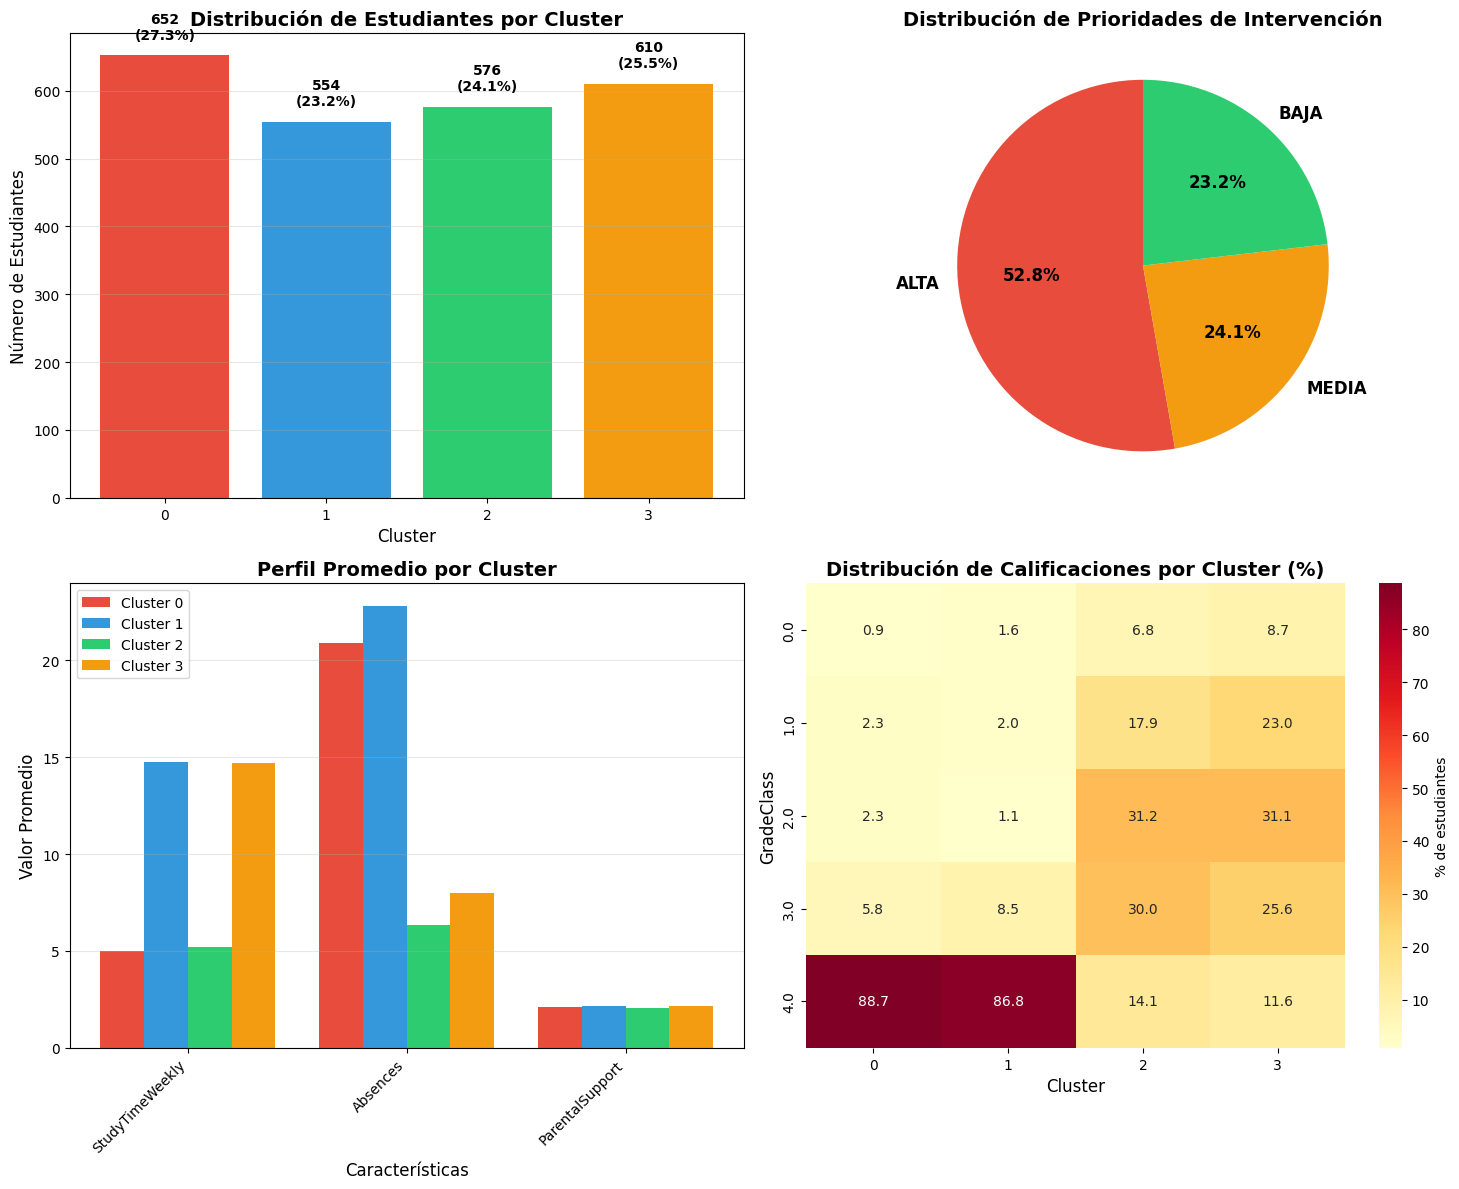


📊 INTERPRETACIÓN DE LAS VISUALIZACIONES:
1️⃣ Distribución de Clusters: Muestra cómo se distribuyen los estudiantes
2️⃣ Prioridades: Indica qué porcentaje requiere intervención urgente
3️⃣ Perfiles: Características promedio que definen cada cluster
4️⃣ Riesgo Académico: Relación entre clusters y calificaciones finales


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Asegúrate de que 'df' esté correctamente definido en tu entorno.
# Preprocesar los datos: eliminar columnas innecesarias y preparar X_all
X_all = df.drop(columns=['StudentID', 'GradeClass', 'GPA'], errors='ignore')

# Verificar los datos de entrada
print(f"Forma de X_all: {X_all.shape}")  # Verificar las dimensiones de X_all
print(f"Primeras filas de X_all:\n{X_all.head()}")  # Mostrar las primeras filas de X_all

# Supongamos que 'sistema' es un modelo que ya está entrenado, y tiene un método de predicción.
# En este caso, usamos KMeans como ejemplo:

from sklearn.cluster import KMeans

# Entrenar un modelo de KMeans para predicciones (esto debería hacerse solo una vez)
modelo = KMeans(n_clusters=4, random_state=42)  # Supongamos que hay 4 clusters
modelo.fit(X_all)  # Entrenamos el modelo

# Predicción para todos los estudiantes
clusters_all = modelo.predict(X_all)

# Verificar el tipo y contenido de clusters_all
print(f"\nTipo de clusters_all: {type(clusters_all)}")
print(f"Contenido de clusters_all: {clusters_all[:5]}")  # Mostrar las primeras predicciones

# Asegúrate de que clusters_all sea un array de predicciones, no un valor único
if isinstance(clusters_all, np.ndarray) and clusters_all.ndim == 1:
    print("La predicción está devolviendo un array con múltiples valores.")
elif isinstance(clusters_all, np.ndarray):
    print(f"Clusters tiene más de una dimensión: {clusters_all.shape}")
else:
    print("El modelo está devolviendo un único valor de cluster, lo cual no es correcto.")
    raise TypeError(f"El modelo está devolviendo un único valor de cluster: {clusters_all}")

# Verificar que clusters_all tenga la misma longitud que el número de estudiantes
if len(clusters_all) != len(df):
    raise ValueError(f"El número de clusters ({len(clusters_all)}) no coincide con el número de estudiantes ({len(df)}).")

# Crear visualizaciones si las predicciones son correctas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribución de clusters
ax1 = axes[0, 0]
cluster_counts = pd.Series(clusters_all).value_counts().sort_index()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
ax1.bar(cluster_counts.index, cluster_counts.values, color=colors)
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Número de Estudiantes', fontsize=12)
ax1.set_title('Distribución de Estudiantes por Cluster', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(cluster_counts)))  # Ajustar los ticks de los ejes x según los clusters
ax1.grid(axis='y', alpha=0.3)

# Agregar etiquetas con porcentajes
total_students = len(clusters_all)
for cluster, count in cluster_counts.items():
    pct = (count / total_students) * 100
    ax1.text(cluster, count + 20, f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Prioridad de intervención por cluster
ax2 = axes[0, 1]
prioridades = {
    0: 'ALTA',
    1: 'BAJA',
    2: 'MEDIA',
    3: 'ALTA'
}
# Asegurarse de que todos los clusters posibles (0, 1, 2, 3) estén cubiertos
prioridad_counts = pd.Series([prioridades.get(c, 'Unknown') for c in clusters_all]).value_counts()
priority_colors = {'ALTA': '#e74c3c', 'MEDIA': '#f39c12', 'BAJA': '#2ecc71', 'Unknown': '#95a5a6'}  # Se agregó color para 'Unknown'
ax2.pie(prioridad_counts.values, labels=prioridad_counts.index, autopct='%1.1f%%',
        colors=[priority_colors[p] for p in prioridad_counts.index],
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Distribución de Prioridades de Intervención', fontsize=14, fontweight='bold')

# 3. Características promedio por cluster
ax3 = axes[1, 0]
features_viz = ['StudyTimeWeekly', 'Absences', 'ParentalSupport']
df_viz = df[features_viz].copy()
df_viz['Cluster'] = clusters_all

cluster_means = df_viz.groupby('Cluster')[features_viz].mean()
x = np.arange(len(features_viz))
width = 0.2

for i, cluster in enumerate(cluster_means.index):  # Iterar a través de los clusters disponibles
    offset = (i - len(cluster_means.index) / 2 + 0.5) * width  # Ajustar el desplazamiento según el número de clusters
    ax3.bar(x + offset, cluster_means.loc[cluster], width,
            label=f'Cluster {int(cluster)}', color=colors[int(cluster)])  # Usar int(cluster) para la indexación del color

ax3.set_xlabel('Características', fontsize=12)
ax3.set_ylabel('Valor Promedio', fontsize=12)
ax3.set_title('Perfil Promedio por Cluster', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(features_viz, rotation=45, ha="right")
ax3.legend(loc='upper left')
ax3.grid(axis='y', alpha=0.3)

# 4. Heatmap de riesgo académico
ax4 = axes[1, 1]
riesgo_map = {
    0: 'Alto',
    1: 'Bajo',
    2: 'Moderado',
    3: 'Alto'
}

# Crear matriz de riesgo por GradeClass y Cluster
df_risk = df[['GradeClass']].copy()
df_risk['Cluster'] = clusters_all
risk_matrix = pd.crosstab(df_risk['GradeClass'], df_risk['Cluster'], normalize='columns') * 100

sns.heatmap(risk_matrix, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4,
            cbar_kws={'label': '% de estudiantes'})
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('GradeClass', fontsize=12)
ax4.set_title('Distribución de Calificaciones por Cluster (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETACIÓN DE LAS VISUALIZACIONES:")
print("=" * 80)
print("1️⃣ Distribución de Clusters: Muestra cómo se distribuyen los estudiantes")
print("2️⃣ Prioridades: Indica qué porcentaje requiere intervención urgente")
print("3️⃣ Perfiles: Características promedio que definen cada cluster")
print("4️⃣ Riesgo Académico: Relación entre clusters y calificaciones finales")


### Reglas Simples por Cluster

#### Cluster 0: Bajo estudio + más ausencias (deportivos)
**Perfil:** Estudiantes jóvenes, masculinos, poco tiempo de estudio, muchas ausencias, participación en deportes.

**Regla:**
- → Asignar **tutor académico obligatorio** 3 veces por semana
- → Enviar **alerta mensual a padres** sobre asistencia y rendimiento
- → Reducir carga de actividades deportivas o ajustar horarios
- → Crear **plan de recuperación de materias atrasadas**

**Prioridad:** 🔴 ALTA

---

#### Cluster 1: Muy estudioso + menos ausencias (musicales)
**Perfil:** Estudiantes mayores, femeninos, muchas horas de estudio, pocas ausencias, participación en música, alto apoyo parental.

**Regla:**
- → Ofrecer **cursos avanzados o de enriquecimiento**
- → Incluir en **programas de mentoría** (peer tutoring)
- → Monitorear para **prevenir burnout académico**
- → Recomendar balance vida-estudio

**Prioridad:** 🟢 BAJA

---

#### Cluster 2: Mucho estudio + apoyo medio
**Perfil:** Estudiantes jóvenes, masculinos, muchas horas de estudio pero menor educación parental, pocas ausencias.

**Regla:**
- → Optimizar **técnicas de estudio eficientes**
- → Evaluar **calidad vs cantidad** de tiempo de estudio
- → Promover participación en **actividades extracurriculares balanceadas**
- → Ofrecer **apoyo psicopedagógico** si es necesario

**Prioridad:** 🟡 MEDIA

---

#### Cluster 3: Poco estudio + más ausencias (voluntariado)
**Perfil:** Estudiantes mayores, femeninos, alta educación parental, poco tiempo de estudio, muchas ausencias, alta participación en voluntariado.

**Regla:**
- → Implementar **plan de recuperación intensivo**
- → Reunión **semanal con consejero** académico
- → Equilibrar **voluntariado con responsabilidades académicas**
- → Control **estricto de asistencia** (notificación diaria si falta)

**Prioridad:** 🔴 ALTA

### Conclusiones y Aplicaciones Prácticas

#### 🎯 Funcionamiento del Sistema

El sistema de recomendación funciona en 3 pasos principales:

1. **Clasificación Automática**: Cada estudiante nuevo es asignado automáticamente a uno de los 4 clusters identificados mediante K-Means, basándose en sus características académicas y personales.

2. **Aplicación de Reglas**: Una vez asignado el cluster, el sistema aplica un conjunto de reglas específicas que incluyen:
   - Nivel de prioridad de intervención
   - Evaluación de riesgo académico
   - Intervenciones específicas recomendadas
   - Recursos educativos sugeridos
   - Alertas y seguimiento necesario

3. **Generación de Plan Personalizado**: El sistema genera un plan de acción detallado y personalizado para cada estudiante o grupo de estudiantes.

#### 📊 Ventajas del Sistema

- **Automatización**: Elimina la necesidad de evaluación manual caso por caso
- **Consistencia**: Aplica criterios uniformes a todos los estudiantes
- **Escalabilidad**: Puede procesar cientos o miles de estudiantes simultáneamente
- **Personalización**: Las recomendaciones se adaptan al perfil específico de cada cluster
- **Proactivo**: Identifica estudiantes en riesgo antes de que fallen académicamente

#### 💡 Aplicaciones Prácticas en el Sector Educativo

1. **Sistema de Alerta Temprana**
   - Identificar estudiantes en riesgo al inicio del semestre
   - Asignar recursos de tutoría de manera eficiente
   - Priorizar intervenciones según nivel de riesgo

2. **Asignación de Recursos**
   - Distribuir tutores según la demanda de cada cluster
   - Crear programas especializados para cada perfil
   - Optimizar el presupuesto educativo

3. **Seguimiento y Monitoreo**
   - Evaluar la efectividad de las intervenciones por cluster
   - Ajustar estrategias según resultados observados
   - Generar reportes automáticos para administradores

4. **Orientación Vocacional**
   - Recomendar actividades extracurriculares según perfil
   - Sugerir estrategias de estudio personalizadas
   - Identificar fortalezas y áreas de mejora

#### 🔄 Mejoras Futuras

- Incorporar datos históricos de rendimiento
- Añadir factores socioeconómicos adicionales
- Implementar retroalimentación del sistema (¿funcionaron las recomendaciones?)
- Integración con sistemas de gestión académica existentes
- Dashboard interactivo para visualización en tiempo real

#### ⚠️ Consideraciones Éticas

- Transparencia en la toma de decisiones del sistema
- Evitar estigmatización de estudiantes en clusters de alto riesgo
- Permitir revisión humana de recomendaciones críticas
- Protección de datos personales de estudiantes
- Actualización periódica del modelo con nuevos datos

## Parcial

In [ ]:
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"
df = pd.read_csv(path)

Using Colab cache for faster access to the 'students-performance-dataset' dataset.


In [ ]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [ ]:
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")
path = path + "/Student_performance_data _.csv"
df = pd.read_csv(path)

Using Colab cache for faster access to the 'students-performance-dataset' dataset.


In [ ]:
# Define the binary target variable: 1 for Pass, 0 for Fail
# Based on the data dictionary, only GradeClass 4.0 is 'F' (Fail)
# Explicitly map GradeClass values: 4.0 -> 0 (Fail), others -> 1 (Pass)
df['target_bin'] = df['GradeClass'].apply(lambda x: 0 if x == 4.0 else 1)

# Display the value counts for the new target variable
print("Value counts for the binary target variable 'target_bin':")
display(df['target_bin'].value_counts())

Value counts for the binary target variable 'target_bin':


,count
target_bin,
0,1211
1,1181


In [ ]:
cols_to_delete = ["StudentID", "GPA", "GradeClass"]
df = df.drop(columns=cols_to_delete)

In [ ]:
Y = df["target_bin"]
X = df.drop(columns=["target_bin"])

**Reasoning**:
Define a preprocessing pipeline to handle numerical features (imputation and scaling) and categorical features (imputation and one-hot encoding).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different preprocessing steps to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) - though we expect none here
)

print("Preprocessing pipeline defined.")
print(f"Numerical features: {list(numerical_features)}")
print(f"Categorical features: {list(categorical_features)}")

Preprocessing pipeline defined.
Numerical features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Categorical features: []


In [ ]:
from sklearn.model_selection import train_test_split

# Perform the stratified split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Data split into:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

print("\nTarget distribution in splits:")
print("  Train:\n", y_train.value_counts(normalize=True))
print("  Validation:\n", y_val.value_counts(normalize=True))
print("  Test:\n", y_test.value_counts(normalize=True))

Data split into:
  Train: 1674 samples
  Validation: 359 samples
  Test: 359 samples

Target distribution in splits:
  Train:
 target_bin
0    0.505974
1    0.494026
Name: proportion, dtype: float64
  Validation:
 target_bin
0    0.506964
1    0.493036
Name: proportion, dtype: float64
  Test:
 target_bin
0    0.506964
1    0.493036
Name: proportion, dtype: float64


**Reasoning**:
Train a K-Means clustering model on the preprocessed training data, choose a reasonable K, and then enrich each data split with clustering information (cluster ID as one-hot, distances to centroids, and probabilities if applicable).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Choose a reasonable K for KMeans (e.g., based on prior exploration or domain knowledge)
# Let's choose K=4 as suggested by the previous K-Means analysis in the notebook.
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Train the KMeans model on the preprocessed training data
kmeans.fit(X_train_processed)

print(f"KMeans model trained with K = {n_clusters}")

# Function to add clustering features to a dataset
def add_clustering_features(X_processed, kmeans_model):
    # Get cluster labels
    cluster_labels = kmeans_model.predict(X_processed)

    # One-hot encode cluster labels
    onehot_encoder = OneHotEncoder(sparse_output=False, categories='auto')
    cluster_labels_onehot = onehot_encoder.fit_transform(cluster_labels.reshape(-1, 1))
    cluster_onehot_names = [f'cluster_{int(i)}' for i in onehot_encoder.categories_[0]]

    # Get distances to centroids
    distances_to_centroids = kmeans_model.transform(X_processed)
    distance_names = [f'distance_to_cluster_{i}' for i in range(kmeans_model.n_clusters)]

    # Concatenate original processed features with new clustering features
    # Ensure the original features are in the correct format if they were pandas DataFrames
    # Since X_processed is a numpy array, we'll concatenate numpy arrays
    X_enriched = np.hstack((X_processed, cluster_labels_onehot, distances_to_centroids))

    # Note: KMeans does not provide membership probabilities directly

    return X_enriched, cluster_onehot_names, distance_names

# Enrich the training, validation, and test sets
X_train_enriched, cluster_onehot_names, distance_names = add_clustering_features(X_train_processed, kmeans)
X_val_enriched, _, _ = add_clustering_features(X_val_processed, kmeans)
X_test_enriched, _, _ = add_clustering_features(X_test_processed, kmeans)

print("\nData splits enriched with clustering features.")
print(f"Shape of enriched training data: {X_train_enriched.shape}")
print(f"Shape of enriched validation data: {X_val_enriched.shape}")
print(f"Shape of enriched test data: {X_test_enriched.shape}")

KMeans model trained with K = 4

Data splits enriched with clustering features.
Shape of enriched training data: (1674, 20)
Shape of enriched validation data: (359, 20)
Shape of enriched test data: (359, 20)


**Reasoning**:
Display feature importances (or SHAP if fast), highlighting the contribution of the clustering features.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the CatBoost model
importances = cat_clf.get_feature_importance()

# Get the names of the processed features
# The order is numerical features first, then one-hot encoded categorical features,
# followed by one-hot encoded cluster labels and distances to centroids.

# Get original numerical and categorical feature names from the preprocessor
numerical_features_names = preprocessor.transformers_[0][2] # Names from the 'num' transformer
categorical_features_names = preprocessor.transformers_[1][2] # Names from the 'cat' transformer

# Get one-hot encoded categorical feature names
# We need to fit the one-hot encoder part of the pipeline to get the feature names
# This requires a dummy fit on some data (e.g., X_train)
preprocessor.transformers_[1][1]['onehot'].fit(X_train[categorical_features_names])
onehot_cat_feature_names = preprocessor.transformers_[1][1]['onehot'].get_feature_names_out(categorical_features_names)

# Combine original feature names (numerical + one-hot encoded categorical)
original_feature_names = list(numerical_features_names) + list(onehot_cat_feature_names)


# Combine original feature names with clustering feature names
# The enriched features were added in the order: original processed, cluster one-hot, distances
all_feature_names = original_feature_names + cluster_onehot_names + distance_names

# Create a DataFrame for importances
df_importances = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

# Sort by importance
df_importances = df_importances.sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importances:")
display(df_importances.head(20))

# Visualize feature importances
plt.figure(figsize=(10, 8))
plt.barh(df_importances['feature'], df_importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from CatBoost Model')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

# Highlight contribution of clustering features
clustering_importance_sum = df_importances[
    df_importances['feature'].str.startswith(('cluster_', 'distance_to_cluster_'))
]['importance'].sum()

print(f"\nTotal importance of clustering features: {clustering_importance_sum:.2f}")

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

**Reasoning**:
Evaluate the trained classifier on the validation and test sets using appropriate metrics (F1-macro, precision, recall, AUC, confusion matrix, PR/ROC curves).

--- Evaluation on Validation Set ---

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       182
           1       0.90      0.90      0.90       177

    accuracy                           0.91       359
   macro avg       0.91      0.91      0.91       359
weighted avg       0.91      0.91      0.91       359



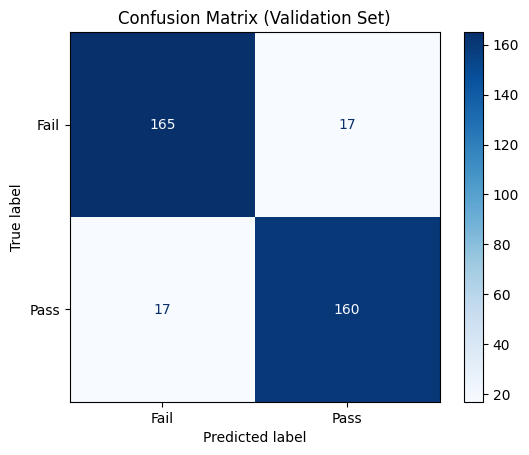

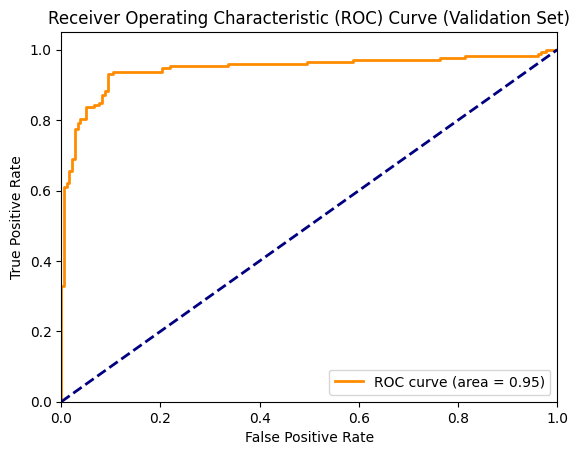

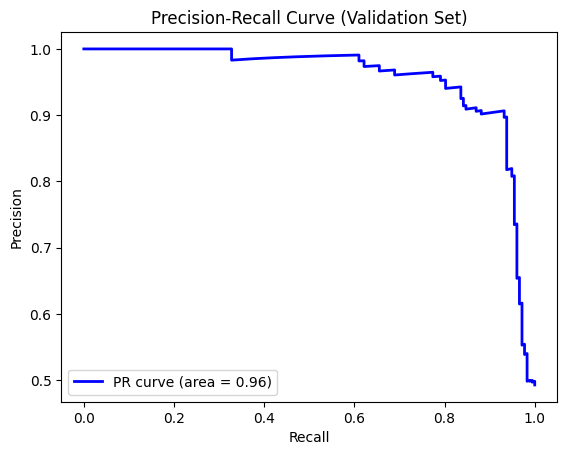


--- Evaluation on Test Set ---

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       182
           1       0.90      0.85      0.87       177

    accuracy                           0.88       359
   macro avg       0.88      0.88      0.88       359
weighted avg       0.88      0.88      0.88       359



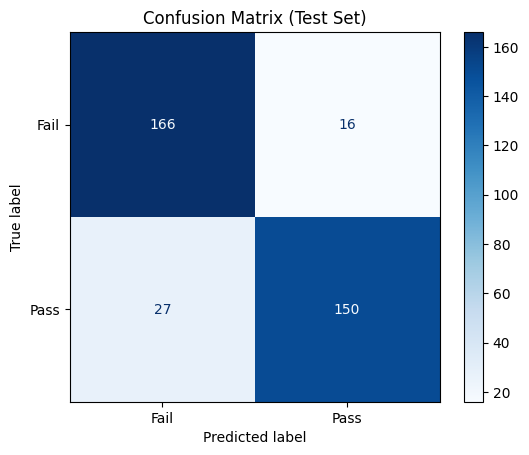

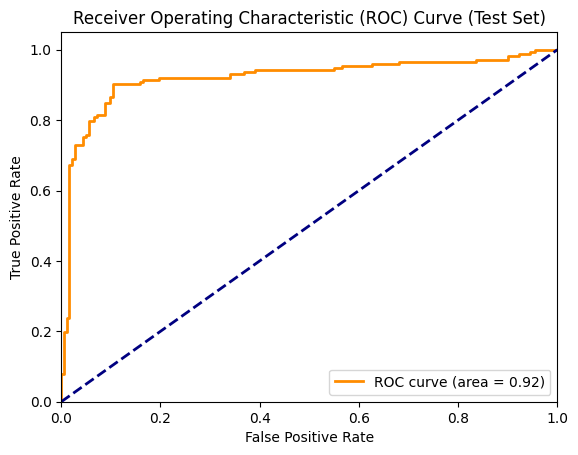

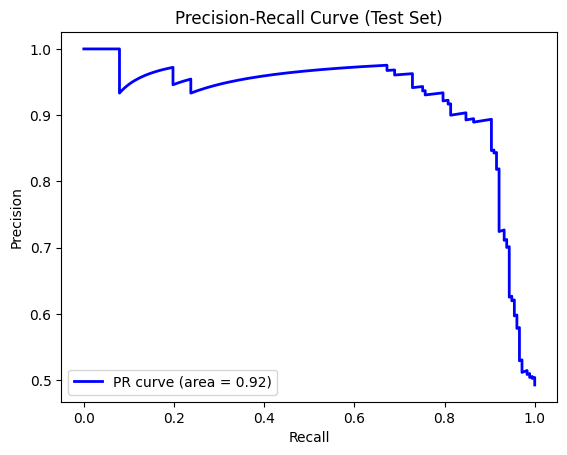

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on Validation Set
print("--- Evaluation on Validation Set ---")
y_val_pred = cat_clf.predict(X_val_enriched)
y_val_prob = cat_clf.predict_proba(X_val_enriched)[:, 1] # Probability of the positive class

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

# Confusion Matrix (Validation)
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Fail', 'Pass'])
disp_val.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Validation Set)')
plt.show()

# ROC Curve and AUC (Validation)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
roc_auc_val = auc(fpr_val, tpr_val)

plt.figure()
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Validation Set)')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve (Validation)
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_prob)
pr_auc_val = auc(recall_val, precision_val)

plt.figure()
plt.plot(recall_val, precision_val, color='blue', lw=2, label=f'PR curve (area = {pr_auc_val:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation Set)')
plt.legend(loc="lower left")
plt.show()


# Evaluate on Test Set
print("\n--- Evaluation on Test Set ---")
y_test_pred = cat_clf.predict(X_test_enriched)
y_test_prob = cat_clf.predict_proba(X_test_enriched)[:, 1] # Probability of the positive class

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Fail', 'Pass'])
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Test Set)')
plt.show()

# ROC Curve and AUC (Test)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Test Set)')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve (Test)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc_test = auc(recall_test, precision_test)

plt.figure()
plt.plot(recall_test, precision_test, color='blue', lw=2, label=f'PR curve (area = {pr_auc_test:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend(loc="lower left")
plt.show()

**Reasoning**:
Train a robust classifier (CatBoost or XGBoost) on the enriched features, compensating for class imbalance if present (e.g., using `scale_pos_weight`).

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

# Check for class imbalance and calculate scale_pos_weight if needed
neg_count = np.sum(y_train == 0)
pos_count = np.sum(y_train == 1)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

print(f"Training data: {neg_count} negative samples, {pos_count} positive samples")
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Initialize and train the CatBoost classifier
# Use verbose=0 to reduce output during training
cat_clf = CatBoostClassifier(
    iterations=300, # Number of boosting iterations
    learning_rate=0.1, # Step size shrinkage used in update to prevent overfitting
    depth=6, # Depth of the trees
    loss_function='Logloss', # Loss function for binary classification
    eval_metric='F1', # Evaluation metric
    random_seed=42, # Random seed for reproducibility
    verbose=0, # Suppress verbose output
    scale_pos_weight=scale_pos_weight # Compensate for class imbalance
)

print("\nTraining CatBoost classifier...")
cat_clf.fit(X_train_enriched, y_train,
            eval_set=(X_val_enriched, y_val), # Evaluate on validation set
            early_stopping_rounds=50) # Stop early if no improvement

print("CatBoost classifier training complete.")

Training data: 847 negative samples, 827 positive samples
Scale pos weight: 1.02

Training CatBoost classifier...
CatBoost classifier training complete.


**Reasoning**:
Perform a stratified train/validation/test split of the data to prepare it for model training and evaluation.

#MDP
#Taller 1 Corte 3